## TP4 - Michel Jean Joseph Donnet

In [1]:
## imports
import numpy as np
import time
import matplotlib.pyplot as plt
import statistics
import random
from joblib import Parallel, delayed

### PART 1 - Monday, October 31, 2022

In [2]:
def cities_coordinates(filename):
    '''
    read .dat file and return a matrix with first column the city names, and coordinate in rest.

    Parameters:
    -----------
    filename

    Returns:
    --------
        matrix of strings
    '''
    return np.genfromtxt(filename, dtype=str)

In [3]:
class AT:
    def __init__(self, cities: np.ndarray, alpha: float = 1, beta: float = 5) -> None:
        '''
        Initialize class AT with a city set, and alpha and beta parameters.
        T : dictionary of pheremone quantities between points (c1, c2)
    
        Parameters:
        -----------
        cities : set of cities that contains at first column city names and in the next two columns
                both x and y coordinate
        alpha : parameter that controls the relative importance of the pheromone
        beta : parameter that controls the relative importance of the heuristic information η_ij
        '''
        self.cities = cities[:, 1:].astype(float)
        self.cities_names = cities[:, 0]
        self.num_cities = cities.shape[0]
        self.distance_matrix = self.compute_distances()
        self.Q = np.mean([self.find_greedy()[1] for _ in range(100)])
        self.T = (np.ones((self.num_cities, self.num_cities)) - np.eye(self.num_cities)) / self.Q
        self.alpha = alpha
        self.beta = beta


    # compute distances between all points and store it into a matrix
    def compute_distances(self):
        # TODO
        '''
        Compute the distances between all points of coordinates of cities and store it into a matrix
        The returned matrix is symetric because distance between city i and j is same than distance between city j and i.

        Returns:
        --------
        M : Matrix with M[i, j] the distance between city i and j.
        '''
        N = len(self.cities_names)
        M = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                M[i, j] = np.linalg.norm(self.cities[i] - self.cities[j])
        assert np.allclose(M, M.T), "Distance matrix must be symetric !"
        return M
 
    # compute fitness by computing length of the path    
    def compute_fitness(self, combination: np.ndarray):
        # TODO
        '''
        compute path length of a combination (of cities)
    
        Parameters:
        -----------
        combination : 1D array of cities' path
    
        Returns:
        --------
        fitness : path length
        '''
        return np.sum(self.distance_matrix[combination, np.roll(combination, 1)])
    
    # compute the probability of choosing a next city from unvisited cities
    def prob_to_city(self, i, j, J):
        # TODO
        '''
        compute the probability of moving from city i to city j (j belongs to J)
    
        Parameters:
        -----------
        i : current city
        j : city belonging to J 
        J : list of unvisited cities
        self.T : dictionary of pheremone quantities between points (c1, c2)
        self.alpha : parameter that controls the relative importance of the pheromone
        self.beta : parameter that controls the relative importance of the heuristic information η_ij
    
        Returns:
        --------
        p : probability to go to city j from city i
        '''
        if j not in J:
            return 0
        numerator = self.T[i, j]**self.alpha * (1 / self.distance_matrix[i, j])**self.beta
        denominator = np.sum([self.T[i, l]**self.alpha * (1 / self.distance_matrix[i, l])**self.beta for l in J])
        return numerator / denominator
    
    
    # find solution by greedy algorithm
    def find_greedy(self):
        # TODO
        '''
        perform the greedy algorithm
    
        Returns:
        --------
        c : path (list)
        fitness : fitness of path
        exec_time : execution time
        '''
        start = time.time()
        path = [np.random.choice(np.arange(self.num_cities).astype(int))]
        for i in range(self.num_cities - 1):
            distance = np.linalg.norm(self.cities - self.cities[path[i]], axis=1)
            distance[path] = np.inf
            path.append(np.argmin(distance))
        end = time.time()
        return np.array(path), self.compute_fitness(np.array(path)), end - start
    
    
    # path of each individual ant (run later in parallel, independent at each time t)
    def ant_path(self):
        # TODO
        '''
        path of each individual ant (out of m ants)
        this function can be parallelized and used later in the main AS function
    
        Returns:
        --------
        c : path (list)
        fitness : fitness of path
        '''
        cities = list(np.arange(self.num_cities))
        visited = [np.random.choice(cities)]
        cities.remove(visited[-1])
        while cities != []:
            probabilities = [self.prob_to_city(visited[-1], cities[i], cities) for i in range(len(cities))]
            visited.append(np.random.choice(cities, p=probabilities))
            cities.remove(visited[-1])
        fitness = self.compute_fitness(np.array(visited))
        Delta = np.zeros_like(self.distance_matrix)
        index = np.arange(len(visited))
        Delta[index, np.roll(index, 1)] = self.Q / fitness
        Delta[np.roll(index, 1), index] = self.Q / fitness
        assert np.allclose(Delta, Delta.T), "Matrix Delta must be symetric !"
        return visited, fitness, Delta
    
    # find solution by Ant System Algorithm
    def find_AS(self, tmax, ants: int = 10, alpha: float = 1, beta: float = 5):
        # TODO
        '''
        perform the Ant System algorithm

        Parameters:
        -----------
        setting : dictionary of cities' coordinates in form k:v
        where k is the city name
        & v are the coordinates (x, y)
        g_fitness : fitness that we get from greedy algorithm (best one)
        dist : a dictionary of distances between all points (c1, c2) in the setting
        t_max : number of iterations 
        ants : number of ants
        alpha : controls the relative importance of the pheromone
        beta : controls the relative importance of the heuristic information η_ij

        Returns:
        --------
        c : path (list)
        fitness : fitness of path
        exec_time : execution time

        NOTE : the function ant_path can be parallelized, since at each iteration, ants are independent
        '''
        start = time.time()
        self.alpha = alpha
        self.beta = beta
        self.T = (np.ones((self.num_cities, self.num_cities)) - np.eye(self.num_cities)) / self.Q
        rho = 0.1
        best_fitness = np.inf
        best_path = None
        for i in range(tmax):
            ants_work = Parallel(n_jobs=-1)(delayed(lambda: self.ant_path())() for _ in range(ants))
            self.T *= (1 - rho)
            for visited, fitness, delta in ants_work:
                self.T += delta
                if fitness < best_fitness:
                    best_path = visited
                    best_fitness = fitness
        return np.array(best_path).astype(int), best_fitness, time.time() - start
    
    # plot the path of a combination
    def plot_path(self, path, title, filename):
        '''
        plot the path of a combination 

        Parameters:
        -----------
        combination : list of cities' path
        setting : dictionary of cities' coordinates in form k:v
        where k is the city name
        & v are the coordinates (x, y)
        title : title of plot
        filename : name to save output figure (can be removed)
        '''

        # get coordinates of each city (in order)
        coords = [self.cities[city] for city in path]
        fig = plt.gcf()
        fig.set_size_inches(15, 15)
        x,y = list(zip(*coords))
        plt.scatter(x, y, c=['r'] + ['k'] * (len(path) - 1))
        plt.title(f'{title}-{self.num_cities}cities')
        plt.gca().set_aspect('equal', adjustable='box')

        data_xrange = plt.xlim()[1] - plt.xlim()[0]
        head_scale = data_xrange * 0.3

        for i in range(len(coords)):
            x,y = list(zip(*(coords[i], coords[(i + 1) % len(coords)])))
            plt.arrow(x[0], y[0], (x[1] - x[0]), (y[1] - y[0]), length_includes_head=True,
              head_width=0.05 * head_scale, head_length=0.05 * head_scale, overhang=0.5, alpha=0.6)
        plt.axis("off")
        plt.savefig(filename)
        plt.show()

    # plot box_plot for statistics    
    def box_plot(self, methods, results):
        '''
        plot statistics' box plot

        Parameters:
        -----------
        setting : dictionary of cities' coordinates in form k:v
        where k is the city name
        & v are the coordinates (x, y)
        methods : list of methods ['greedy', 'AS']
        results : path, fitness, and execution time results of each method
        '''
        # for every setting, for every method, plot fitness boxplot
        boxes = {m: results[m]['fitness'] for m in methods}
        fig, ax = plt.subplots()
        ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))

        plt.title(f'Fitness Distribution for {self.num_cities} cities')
        plt.savefig(f'Fitness Distribution for {self.num_cities} cities')
        plt.show(fig)
        plt.close(fig)

    def compare_methods(self, tmax: int = 80, ants: int = 30, alpha: float = 1, beta: float = 5, filename=None, sa: bool = False):
        # TODO (Some Parts)
        '''
        compare greedy & AS methods, output statistics to file + box_plot, & plot paths for initial, best greedy, and best AS 

        Parameters:
        -----------
        setting : dictionary of cities' coordinates in form k:v
        where k is the city name
        & v are the coordinates (x, y)
        t_max : number of iterations 
        ants : number of ants
        alpha : controls the relative importance of the pheromone
        beta : controls the relative importance of the heuristic information η_ij

        Returns:
        --------
        c : path (list)
        fitness : fitness of path
        exec_time : execution time

        NOTE : the function ant_path can be parallelized, since at each iteration, ants are independent
        '''
        if sa:
            methods = ('greedy', 'AS', 'SA')
        else:
            methods = ('greedy', 'AS')
        results = dict.fromkeys(methods)
        for m in methods:
            results[m] = {
                'path': [],
                'fitness': [],
                'exec_time': []
            }

        #run greedy 10 times
        for _ in range(10):
            path, fitness, exec_time = self.find_greedy()
            results['greedy']['path'].append(path)
            results['greedy']['fitness'].append(fitness)
            results['greedy']['exec_time'].append(exec_time)

        ## TODO --------------------------------
        # get g_fitness (L_nn), best solution of the greedy algorithm
        self.Q = np.min(results['greedy']['fitness'])
        # --------------------------------------

        #run AS 5 times
        for _ in range(5):
            path, fitness, exec_time = self.find_AS(tmax=tmax, ants=ants, alpha=alpha, beta=beta)
            results['AS']['path'].append(path)
            results['AS']['fitness'].append(fitness)
            results['AS']['exec_time'].append(exec_time)
        #run SA 5 times
        if sa:
            for _ in range(5):
                path, fitness, exec_time = self.simulated_annealing(threshold=0.05, T_schedule=0.95)
                results['SA']['path'].append(path)
                results['SA']['fitness'].append(fitness)
                results['SA']['exec_time'].append(exec_time)

        self.box_plot( methods, results)

        # for every method, print statistics 
        min_greedy_fitness = min(results['greedy']['fitness'])
        std_greedy_fitness = statistics.stdev(results['greedy']['fitness'])
        mean_greedy_fitness = statistics.mean(results['greedy']['fitness'])
        std_greedy_exec = statistics.stdev(results['greedy']['exec_time'])
        mean_greedy_exec = statistics.mean(results['greedy']['exec_time'])
        min_greedy_path = results['greedy']['path'][results['greedy']['fitness'].index(min_greedy_fitness)]
        min_as_fitness = min(results['AS']['fitness'])
        std_as_fitness = statistics.stdev(results['AS']['fitness'])
        mean_as_fitness = statistics.mean(results['AS']['fitness'])
        std_as_exec = statistics.stdev(results['AS']['exec_time'])
        mean_as_exec = statistics.mean(results['AS']['exec_time'])
        min_as_path = results['AS']['path'][results['AS']['fitness'].index(min_as_fitness)]
        if sa:
            min_sa_fitness = min(results['SA']['fitness'])
            std_sa_fitness = statistics.stdev(results['SA']['fitness'])
            mean_sa_fitness = statistics.mean(results['SA']['fitness'])
            std_sa_exec = statistics.stdev(results['SA']['exec_time'])
            mean_sa_exec = statistics.mean(results['SA']['exec_time'])
            min_sa_path = results['SA']['path'][results['SA']['fitness'].index(min_sa_fitness)]
            outfile = "Results_with_SA"
            if filename:
                outfile += "_" + filename
            outfile += ".txt"
            f = open(outfile, "a")
            s0 = f'\n For {self.num_cities} cities:\n'
            s1 = f'Greedy: Best Path = {min_greedy_path}, Minimum Fitness = {min_greedy_fitness}, Mean Fitness= {mean_greedy_fitness}, Std Fitness= {std_greedy_fitness}, Mean exec_time= {mean_greedy_exec}, Std exec_time= {std_greedy_exec}\n'
            s2 = f'AS: Best Path = {min_as_path}, Minimum Fitness = {min_as_fitness}, Mean Fitness= {mean_as_fitness}, Std Fitness= {std_as_fitness}, Mean exec_time= {mean_as_exec}, Std exec_time= {std_as_exec}\n'
            s3 = f'SA: Best Path = {min_sa_path}, Minimum Fitness = {min_sa_fitness}, Mean Fitness= {mean_sa_fitness}, Std Fitness= {std_sa_fitness}, Mean exec_time= {mean_sa_exec}, Std exec_time= {std_sa_exec}\n'
            f.write(s0+s1+s2+s3)
            f.close()
        else:
            outfile = "Results"
            if filename:
                outfile += "_" + filename
            outfile += ".txt"
            f = open(outfile, "a")
            s0 = f'\n For {self.num_cities} cities:\n'
            s1 = f'Greedy: Best Path = {min_greedy_path}, Minimum Fitness = {min_greedy_fitness}, Mean Fitness= {mean_greedy_fitness}, Std Fitness= {std_greedy_fitness}, Mean exec_time= {mean_greedy_exec}, Std exec_time= {std_greedy_exec}\n'
            s2 = f'AS: Best Path = {min_as_path}, Minimum Fitness = {min_as_fitness}, Mean Fitness= {mean_as_fitness}, Std Fitness= {std_as_fitness}, Mean exec_time= {mean_as_exec}, Std exec_time= {std_as_exec}\n'
            f.write(s0+s1+s2)
            f.close()

            ## TODO --------------------------------
            # choose initial combination 
            initial = np.arange(self.num_cities)
            np.random.shuffle(initial)
            # shuffle initial
            # --------------------------------------
            self.plot_path(initial, 'Initial', f"path_initial_{self.num_cities}.png")
            self.plot_path(min_greedy_path, 'Greedy', f"path_greedy_{self.num_cities}.png")
            self.plot_path(min_as_path, 'AS', f"path_AS_{self.num_cities}_{tmax}_{ants}_{alpha}_{beta}.png")


    def compare_AS_tmax(self, ants: int = 20, alpha: float = 1, beta: float = 5):
        # TODO (Some Parts)
        '''
        compare AS algorithm for different tmax & plot

        Parameters:
        -----------
        setting : dictionary of cities' coordinates in form k:v
        where k is the city name
        & v are the coordinates (x, y)
        dist : a dictionary of distances between all points (c1, c2) in the setting
        g_fitness : fitness that we get from greedy algorithm (best one)
        ants : number of ants
        alpha : controls the relative importance of the pheromone
        beta : controls the relative importance of the heuristic information η_ij
        '''
        ## TODO --------------------------------
        # different possibilities of tmax
        tmax = [20, 30, 40, 50, 60, 70, 80]
        # --------------------------------------
        all_c = []
        all_fitness = []
        all_exec_time = []
        for t in tmax:
            results = Parallel(n_jobs=-1)(delayed(lambda: self.find_AS(tmax=t, ants=ants, alpha=alpha, beta=beta))() for _ in range(10))
            all_fitness.append(np.mean([row[1] for row in results]))
            all_exec_time.append(np.mean([row[2] for row in results]))
        plt.plot(tmax, all_fitness, c='b')
        plt.xlabel("Tmax")
        plt.ylabel("Fitness")
        plt.savefig("Fitness-Iterations.png")
        plt.show()
        plt.plot(tmax, all_exec_time, c='r')
        plt.xlabel("Tmax")
        plt.ylabel("Execution Time")
        plt.savefig("Time-Tmax.png")
        plt.show()

    def compare_AS_ants(self, tmax: int = 100, alpha: float = 1, beta: float = 5):
        '''
        compare AS algorithm for different tmax & plot

        Parameters:
        -----------
        setting : dictionary of cities' coordinates in form k:v
        where k is the city name
        & v are the coordinates (x, y)
        dist : a dictionary of distances between all points (c1, c2) in the setting
        g_fitness : fitness that we get from greedy algorithm (best one)
        t_max : number of iterations 
        alpha : controls the relative importance of the pheromone
        beta : controls the relative importance of the heuristic information η_ij
        '''
        ## TODO --------------------------------
        # different possibilities of ants
        ants = [10, 15, 20, 30, 40]
        # --------------------------------------
        # self.Q = g_fitness
        all_c = []
        all_fitness = []
        all_exec_time = []
        for m in ants:
            results = Parallel(n_jobs=-1)(delayed(lambda: self.find_AS(tmax=tmax, ants=m, alpha=alpha, beta=beta))() for _ in range(10))
            all_fitness.append(np.mean([row[1] for row in results]))
            all_exec_time.append(np.mean([row[2] for row in results]))
        plt.plot(ants, all_fitness, c='b')
        plt.xlabel("Number of ants")
        plt.ylabel("Fitness")
        plt.savefig("Fitness-Ants.png")
        plt.show()
        plt.plot(ants, all_exec_time, c='r')
        plt.xlabel("Number of ants")
        plt.ylabel("Execution Time")
        plt.savefig("Time-Ants.png")
        plt.show()

    def _swap(self, path: np.ndarray, i: int, j: int) -> np.ndarray:
        # Swap 2 given cities
        swap_path = path.copy()
        swap_path[i], swap_path[j] = swap_path[j], swap_path[i]
        return swap_path

    def permute(self, path: np.ndarray) -> np.ndarray:
        # Permute 2 cities randomly
        i, j = np.random.choice(len(path), size=2)
        return self._swap(path, i, j)

    def init_temperature(self, path: np.ndarray, threshold: float = 0.5) -> float:
        # Choose initial temperature according to global fitness variance
        cost = self.compute_fitness(path)
        delta = []
        for _ in range(100):
            delta.append(self.compute_fitness(np.random.permutation(self.num_cities)) - cost)
        return -np.mean(np.abs(delta)) / np.log(threshold)

    def simulated_annealing(
        self,
        threshold: float = 0.05,
        T_schedule: float = 0.9,
        enhanced_mode: bool = False,
    ) -> tuple:
        # Initialize configuration and variables
        start = time.time()
        if enhanced_mode:
            path, _ = self.find_greedy()
        else:
            path = np.random.permutation(self.num_cities)
        current = path
        delta = []
        accepted = 0
        attempted = 0
        freezing = 0
        cost_improvment = False
        best_fitness = self.compute_fitness(current)
        best_path = path
        iter = 0
        list_fitness =  [best_fitness]

        # Initialize temperature
        T = self.init_temperature(path, threshold)
        T_0 = T
        delta = 0
        current = path

        # Stopping condition
        while freezing <= 3:
            # Equilibrum conditions
            if attempted >= self.num_cities * 100 or accepted >= self.num_cities * 12:
                if cost_improvment:
                    freezing = 0
                else:
                    freezing += 1
                cost_improvment = False
                attempted = 0
                accepted = 0
                T *= T_schedule

            # Choose new path
            new_path = self.permute(current)
            delta = self.compute_fitness(new_path) - self.compute_fitness(current)
            if delta <= 0:
                current = new_path
                accepted += 1
                list_fitness.append(self.compute_fitness(current))

            # Metropolis rule
            elif np.random.rand() < np.exp(-delta / T):
                current = new_path
                accepted += 1
                list_fitness.append(self.compute_fitness(current))

            attempted += 1

            # Update best solution
            if self.compute_fitness(current) < best_fitness:
                cost_improvment = True
                best_fitness = self.compute_fitness(current)
                best_path = current.copy()

            iter += 1

        return best_path, best_fitness, time.time() - start




In [4]:
data = cities_coordinates("../data/cities.dat")
data2 = cities_coordinates("../data/cities2.dat")
at1 = AT(data)
at2 = AT(data2)
results = at2.find_greedy()
print(f"Greedy path: {results[0]}")
print(f"Greedy fitness: {results[1]}")
print(f"Greedy time: {results[2]}")
# at2.compare_AS_tmax()
# results = at2.find_AS(tmax=100, ants=20)
# print(f"AS path: {results[0]}")
# print(f"AS fitness: {results[1]}")
# print(f"AS time: {results[2]}")
# print(at2.ant_path()[:2])

Greedy path: [37 29 26 31 33 35 39 41 44 46 42 34 10  7 13 17 22 24 20 16 18 27 30 32
 23 25 36 38 28 15 19  8 12  5  6  9 11 14  2  0  1  3  4 45 48 47 40 43
 21]
Greedy fitness: 3.3132558544610955
Greedy time: 0.00032067298889160156


##### NOTE: Completing the AS algorithm (function find_AS) is included in Part 2 of this TP (due Nov 7th), thus will not be part of the evaluation for Part 1. However, it is highly advised to try to work on it during TP4 Part1 if time permits, so that we can give feedback to aid for Part 2. 

### PART 2 - Monday, November 7, 2022

In [49]:
# dictionary of coordinates of cities from 'cities.dat' file
d_c1 = cities_coordinates('../data/cities.dat')
# dictionary of coordinates of cities from 'cities2.dat' file
d_c2 = cities_coordinates('../data/cities2.dat')

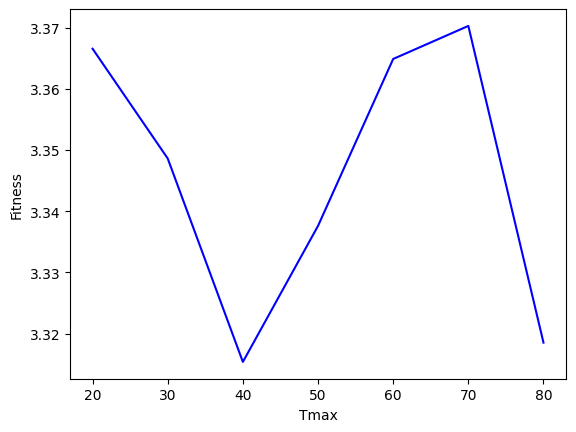

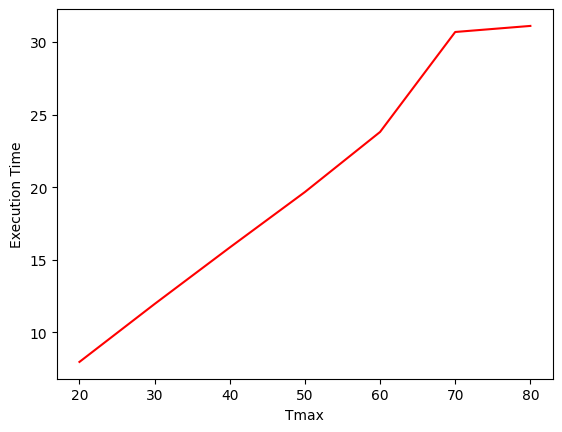

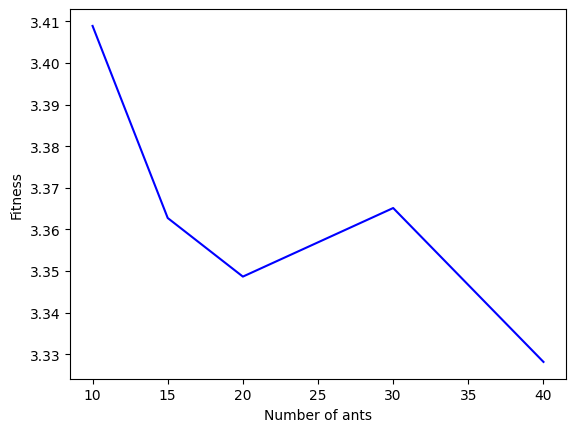

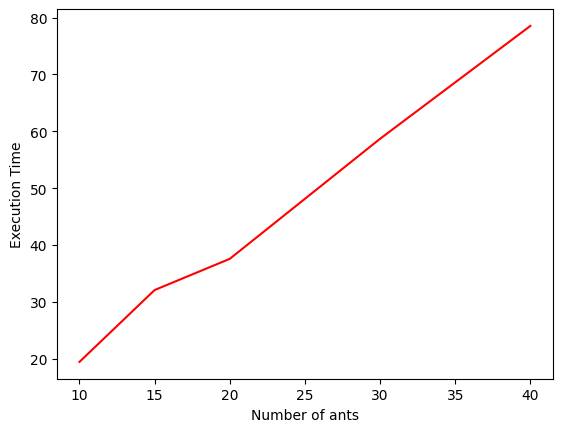

In [37]:
## Study effect of parameters, example on 'cities2.dat' file
# Tmax variation
at2.compare_AS_tmax()
# Number of Ants variation
at2.compare_AS_ants()

#### Comment on the results (effect of t_max & number of ants)

### t_max

As we can see on the graph that shows fitness depending on number of iterations, more iterations we have, greater is our fitness.
However, the execution time increase linearly depending on the number of iterations.
This is due to more iterations we made, more computation we have to do.

We can constate another thing: plots can differs a lot from each execution, and can fluctuate significantly even if a mean of $10$ execution is made for each value.
It means that this method is not very stable, and can give sometimes smaller values for a small number of iterations against bigger fitness for bigger number of iterations.
It's due to the stochasticity of the method and the size of the search space: as the search space is huge and each ant walks inside thanks to probabilities and pheromones, sometimes better solutions can't be explored because of not enough iterations or not enough ants.
In our case, $80$ iterations is not a lot for a search space of order of $18! \approx 6 \times 10^{15}$.
That's why, results can varies a lot between two executions.

### number of ants

As we can see on the graph that shows fitness depending on number of ants, more we have ants, greater is the result.
It's normal because more ants we have, more the search space will be explored, so more chance we have to find a good solution.
But it requires more computations, which increase the execution time in linear way, as shown on the plot of the execution time.

As for t_max, plots can varies a lot because the method is not very stable between each execution.
So as for t_max, an average of results is plotted to have better idea of what's appening.

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_12272\1439634510.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


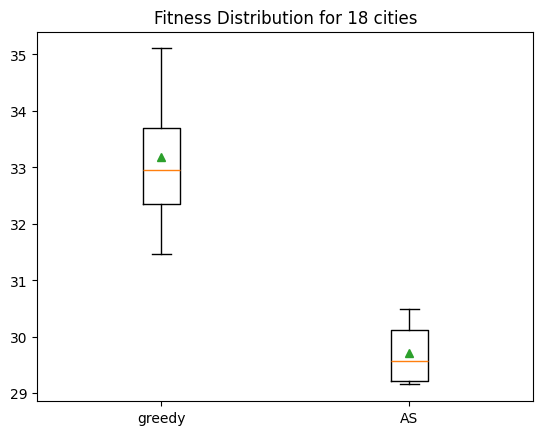

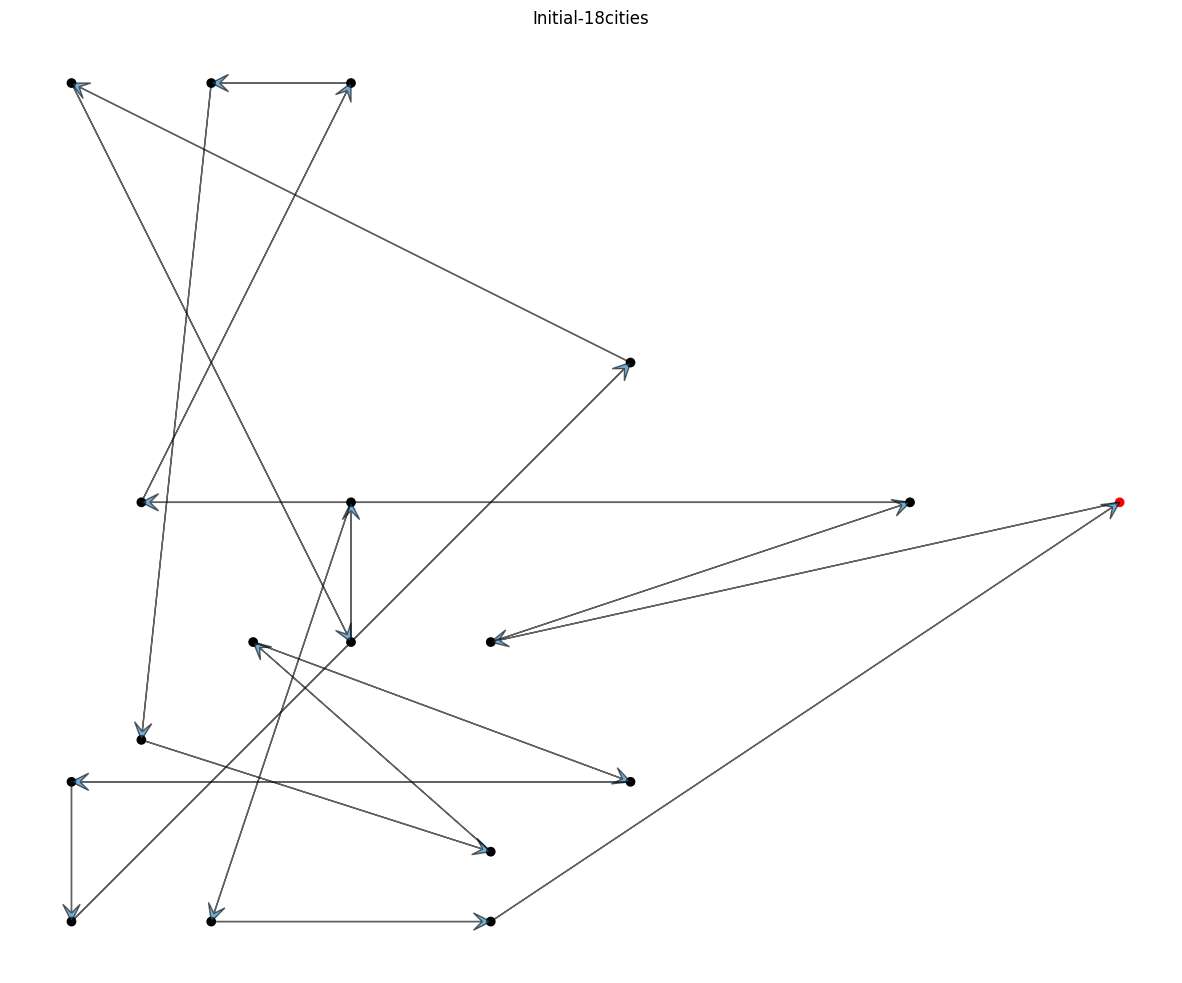

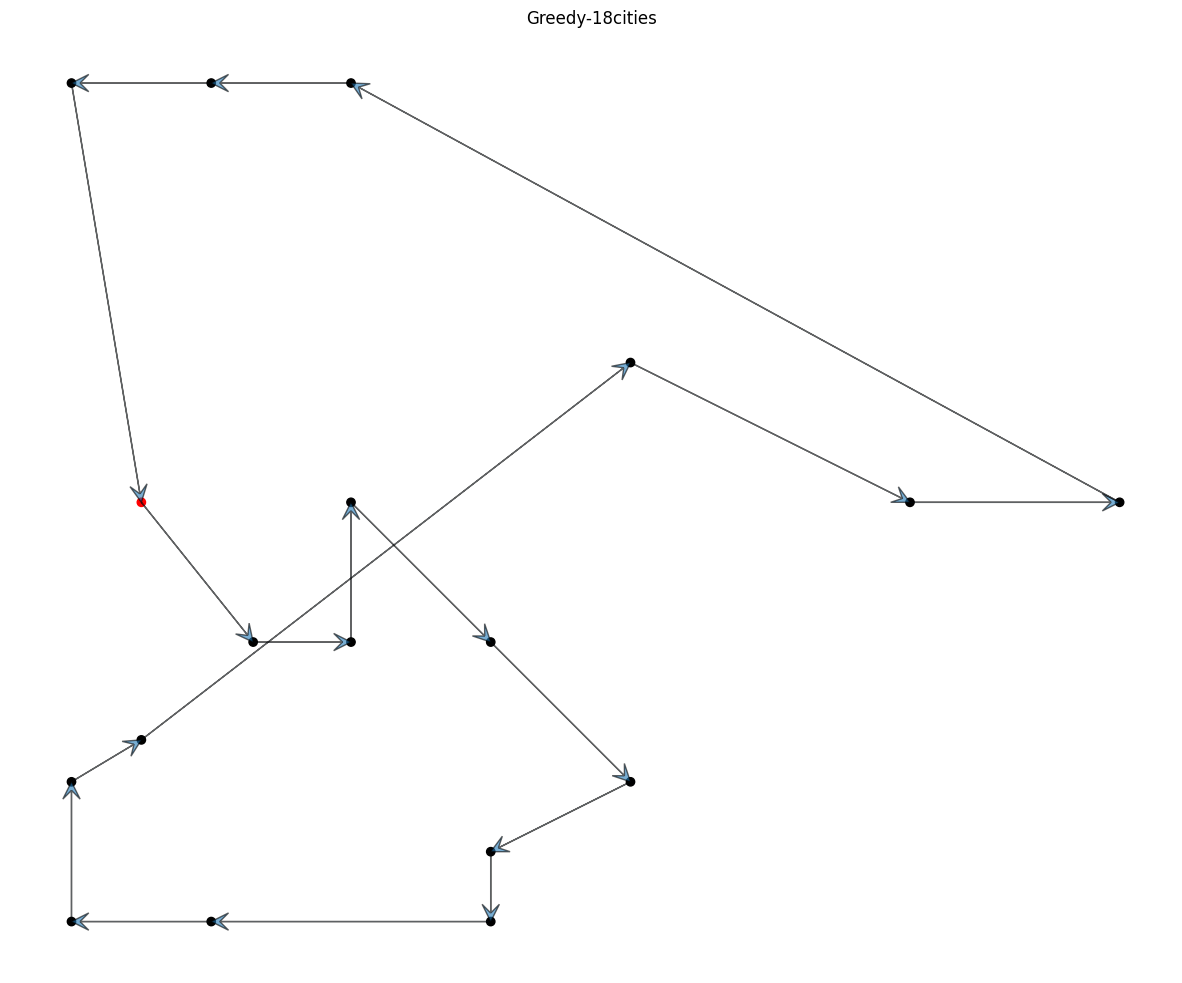

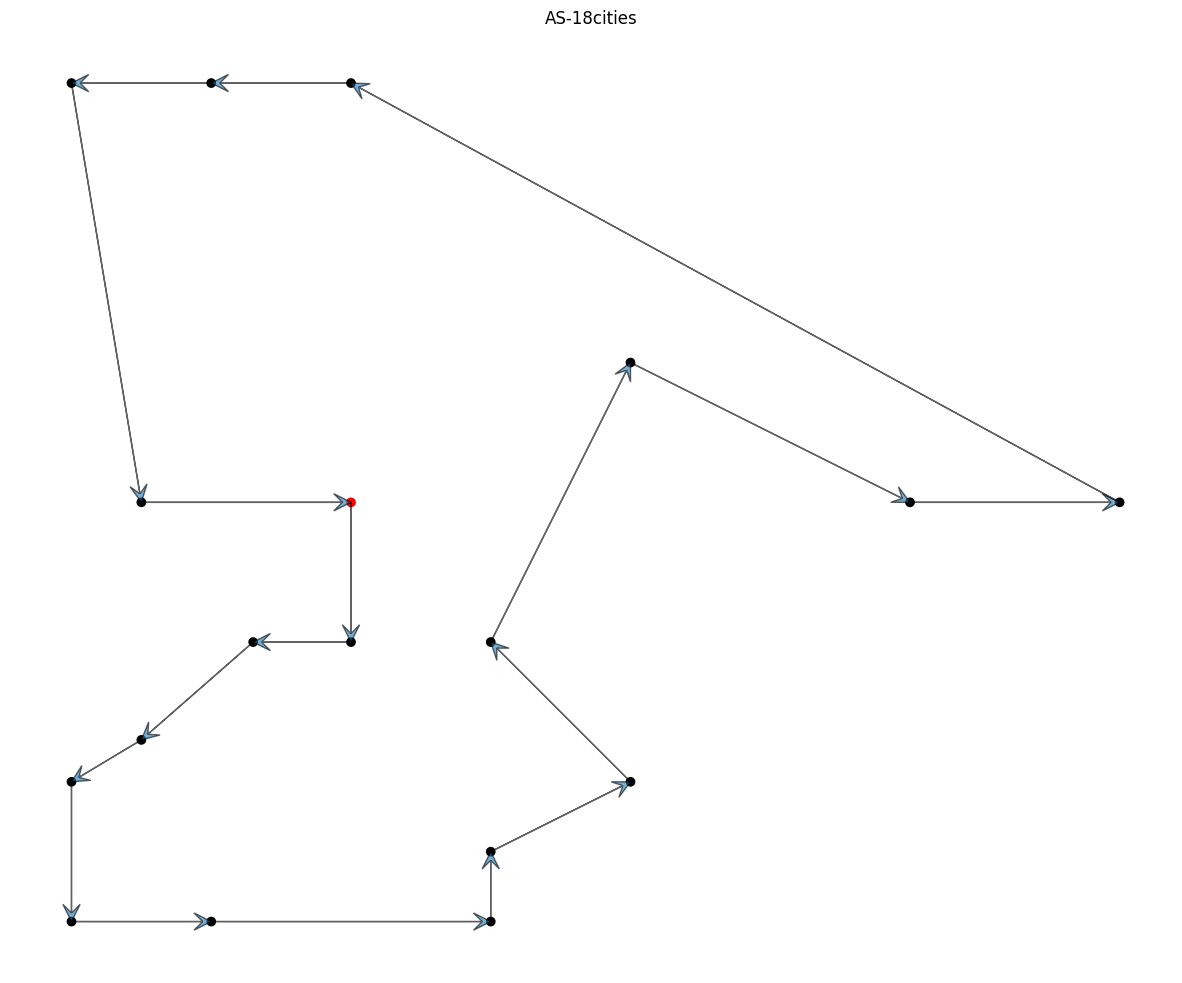

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_12272\1439634510.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


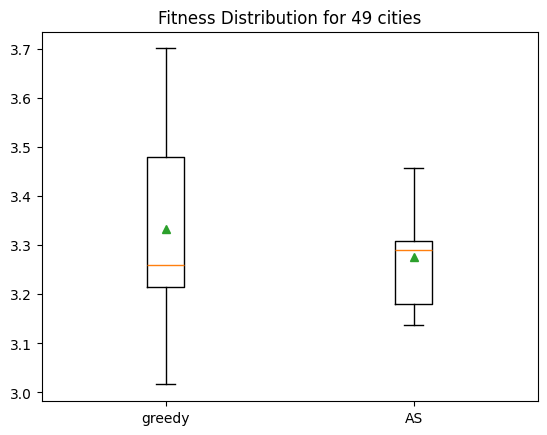

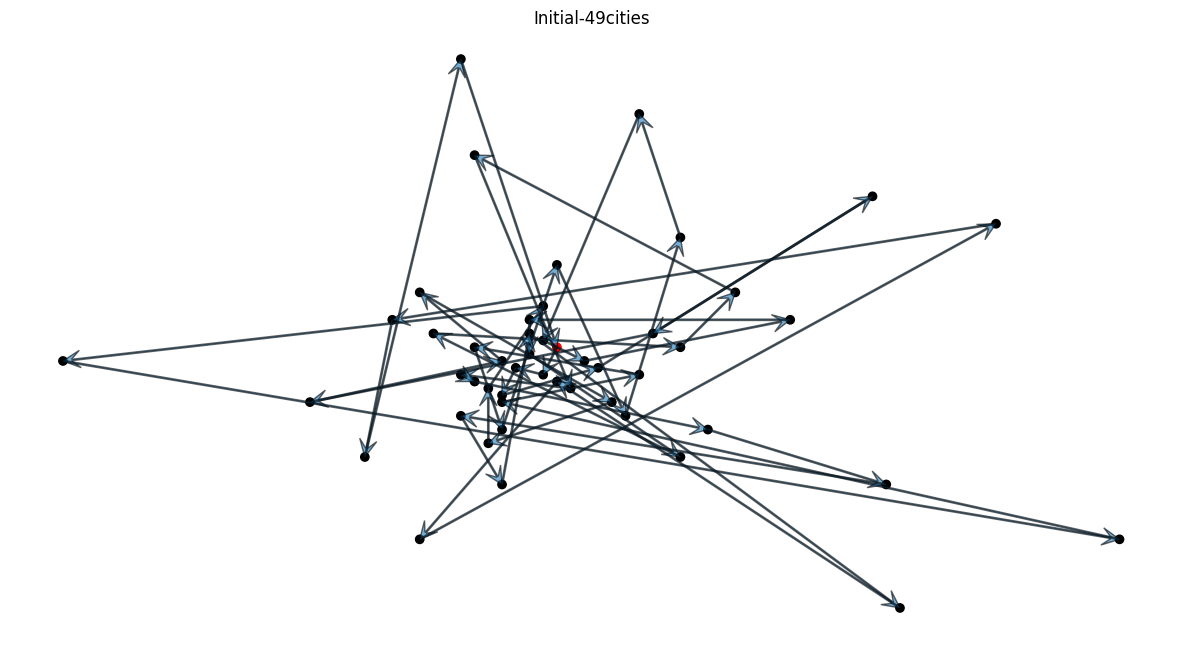

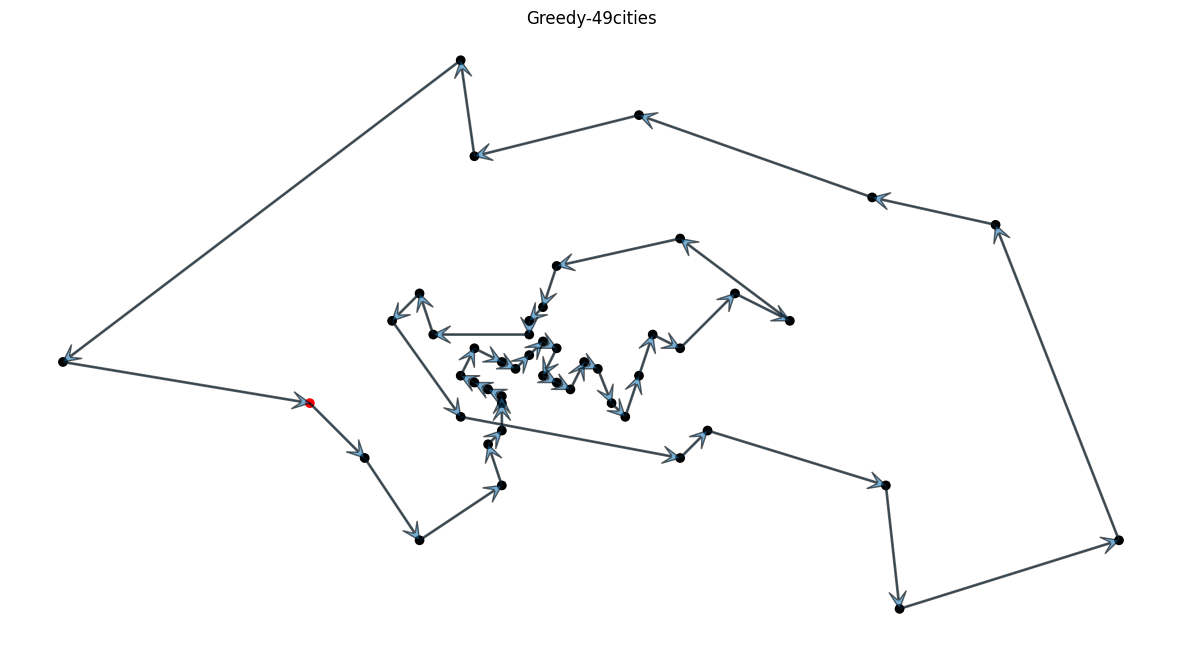

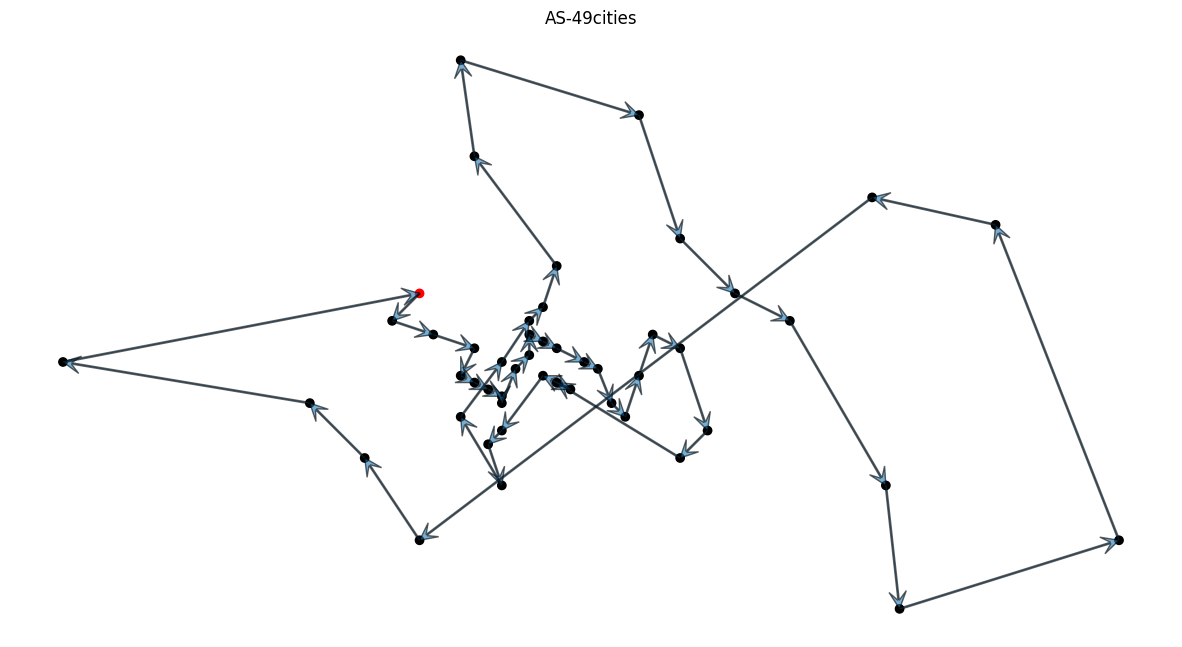

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_12272\1439634510.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


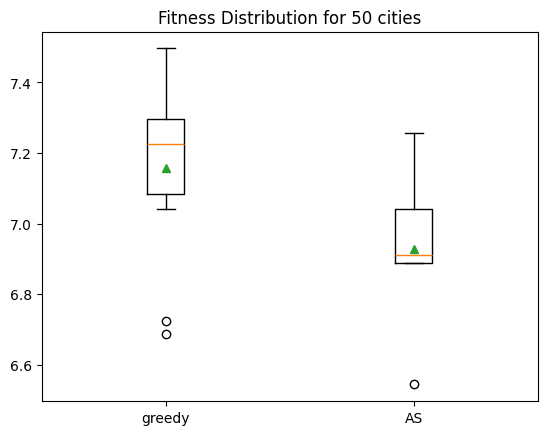

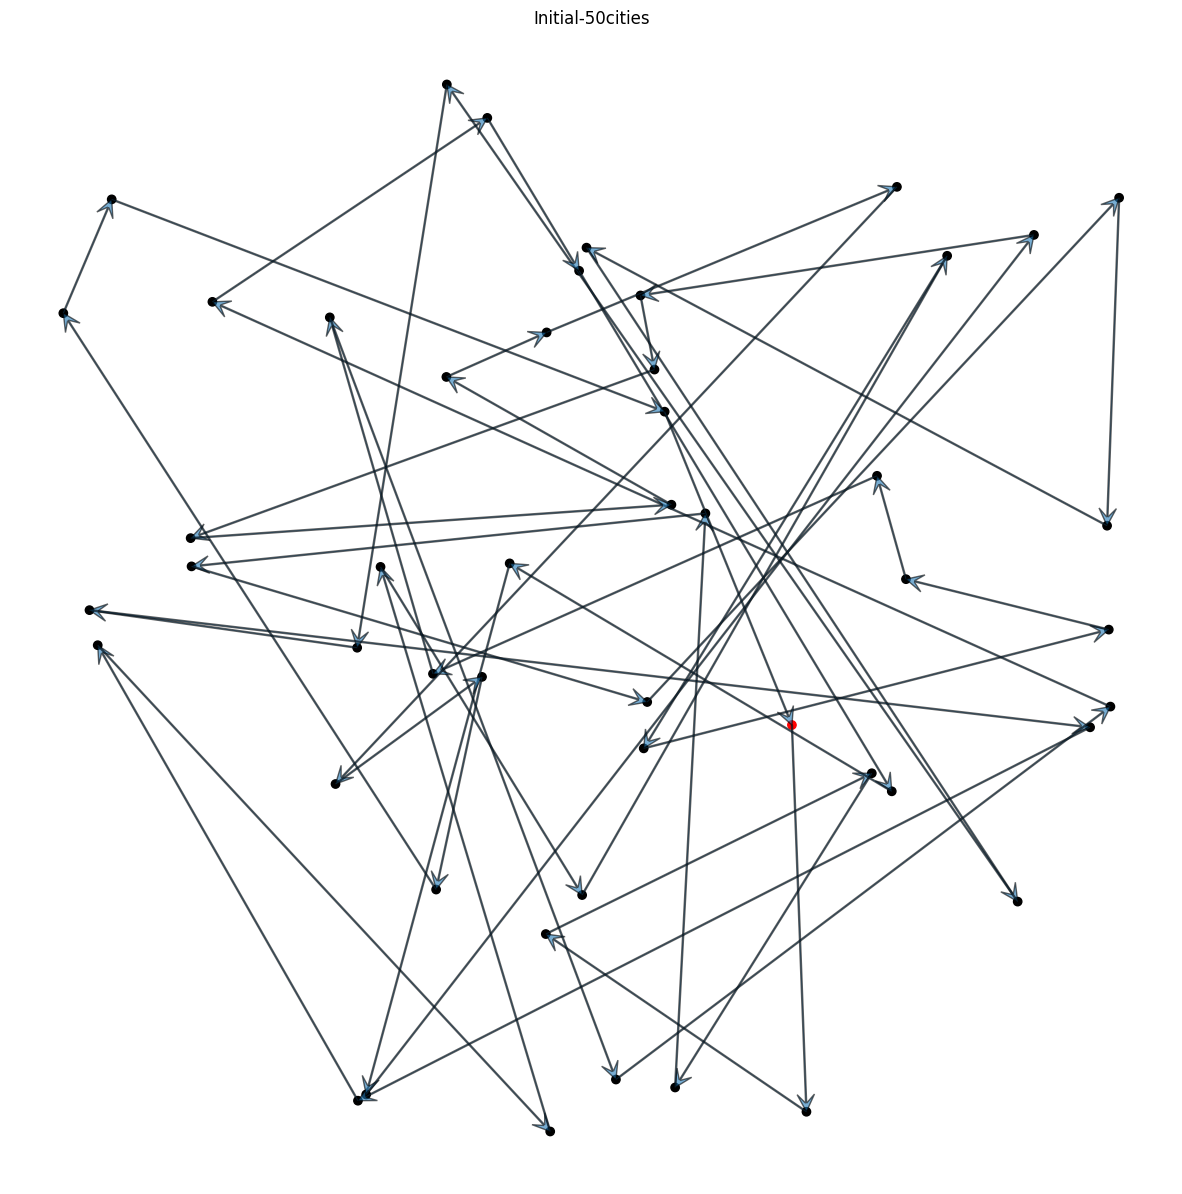

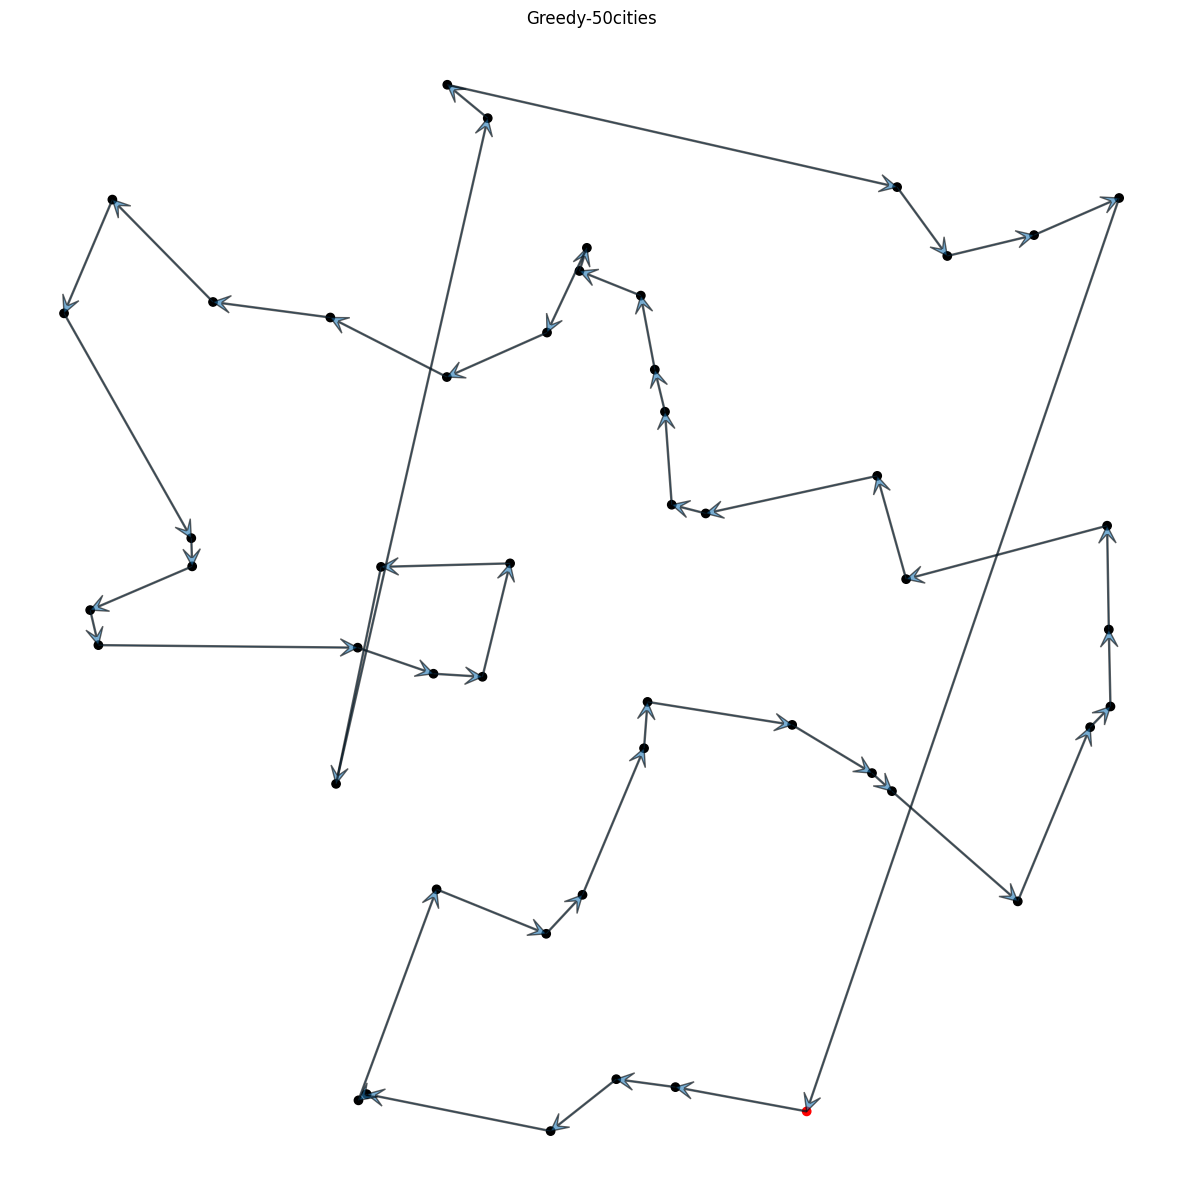

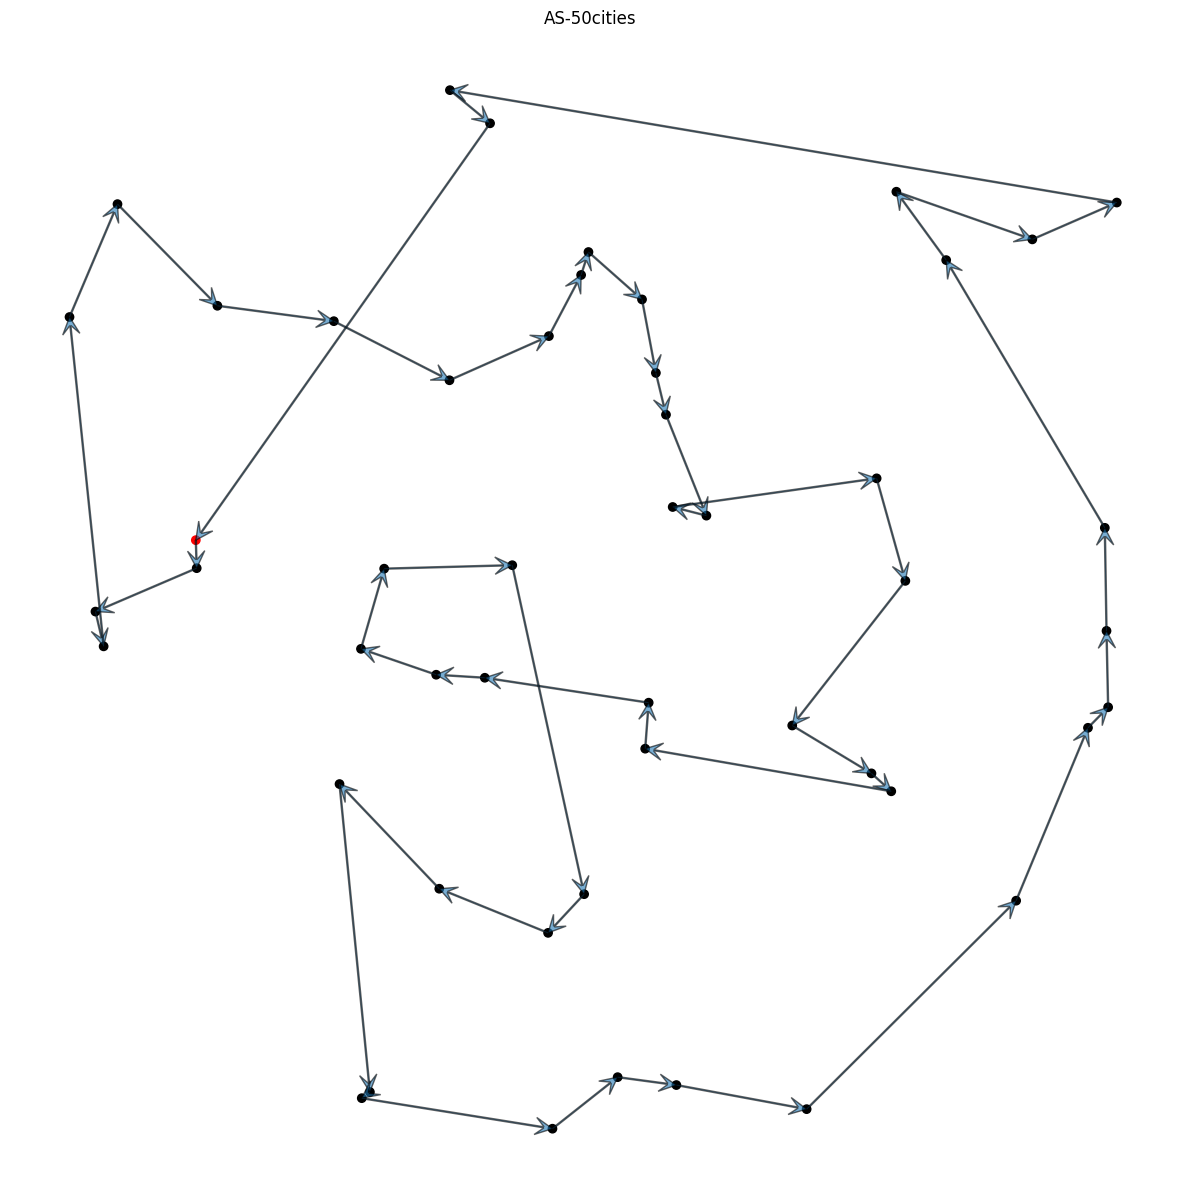

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_12272\1439634510.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


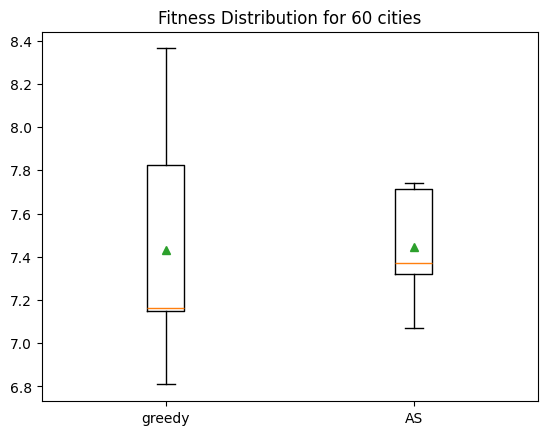

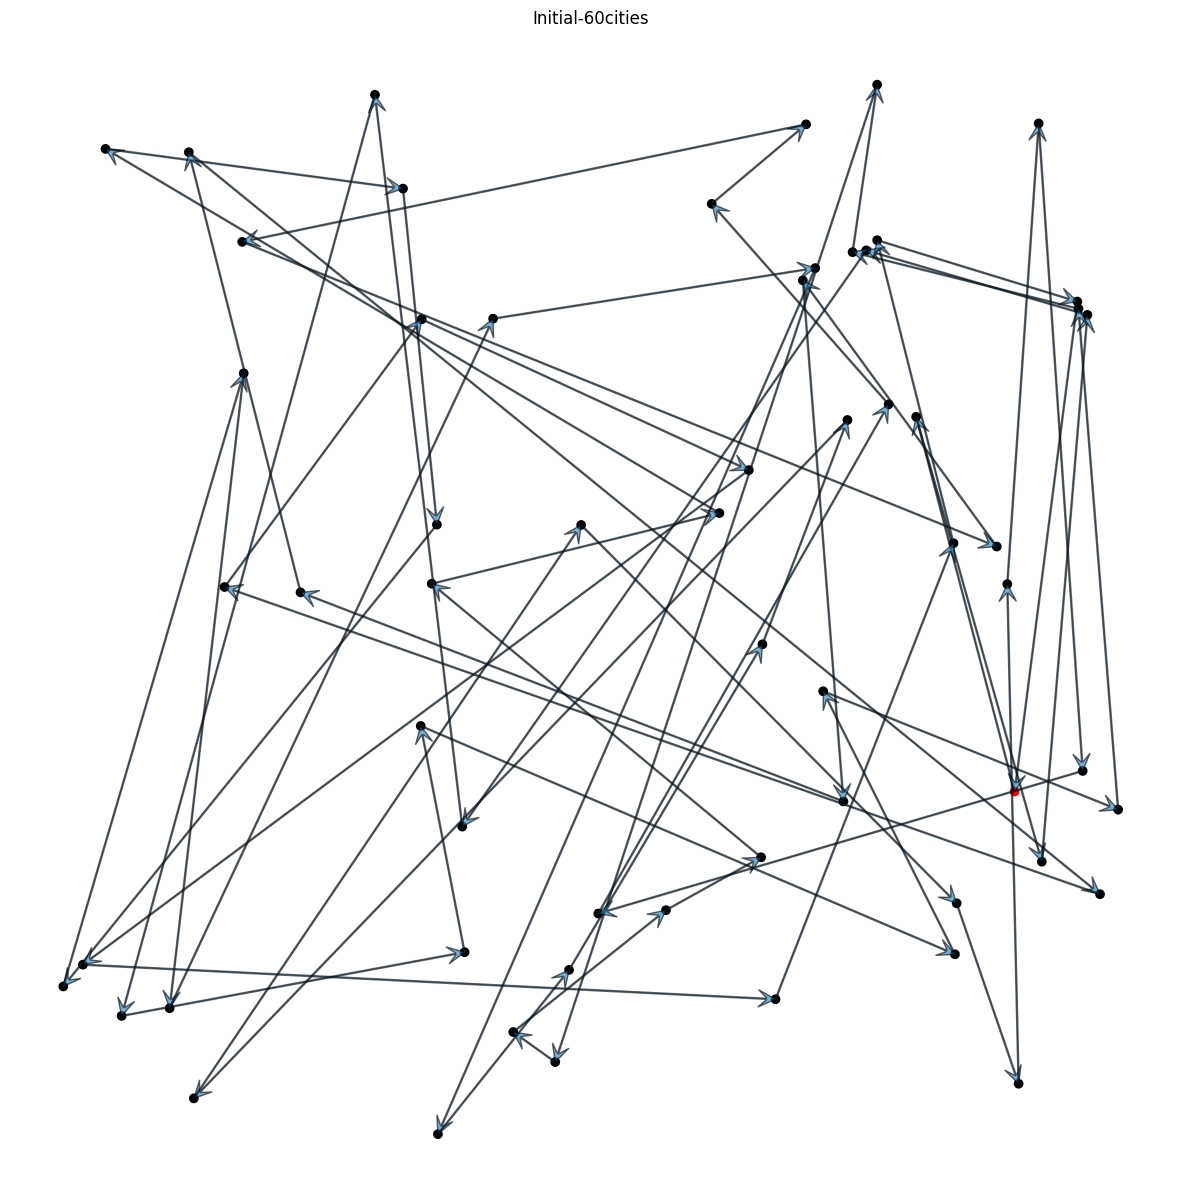

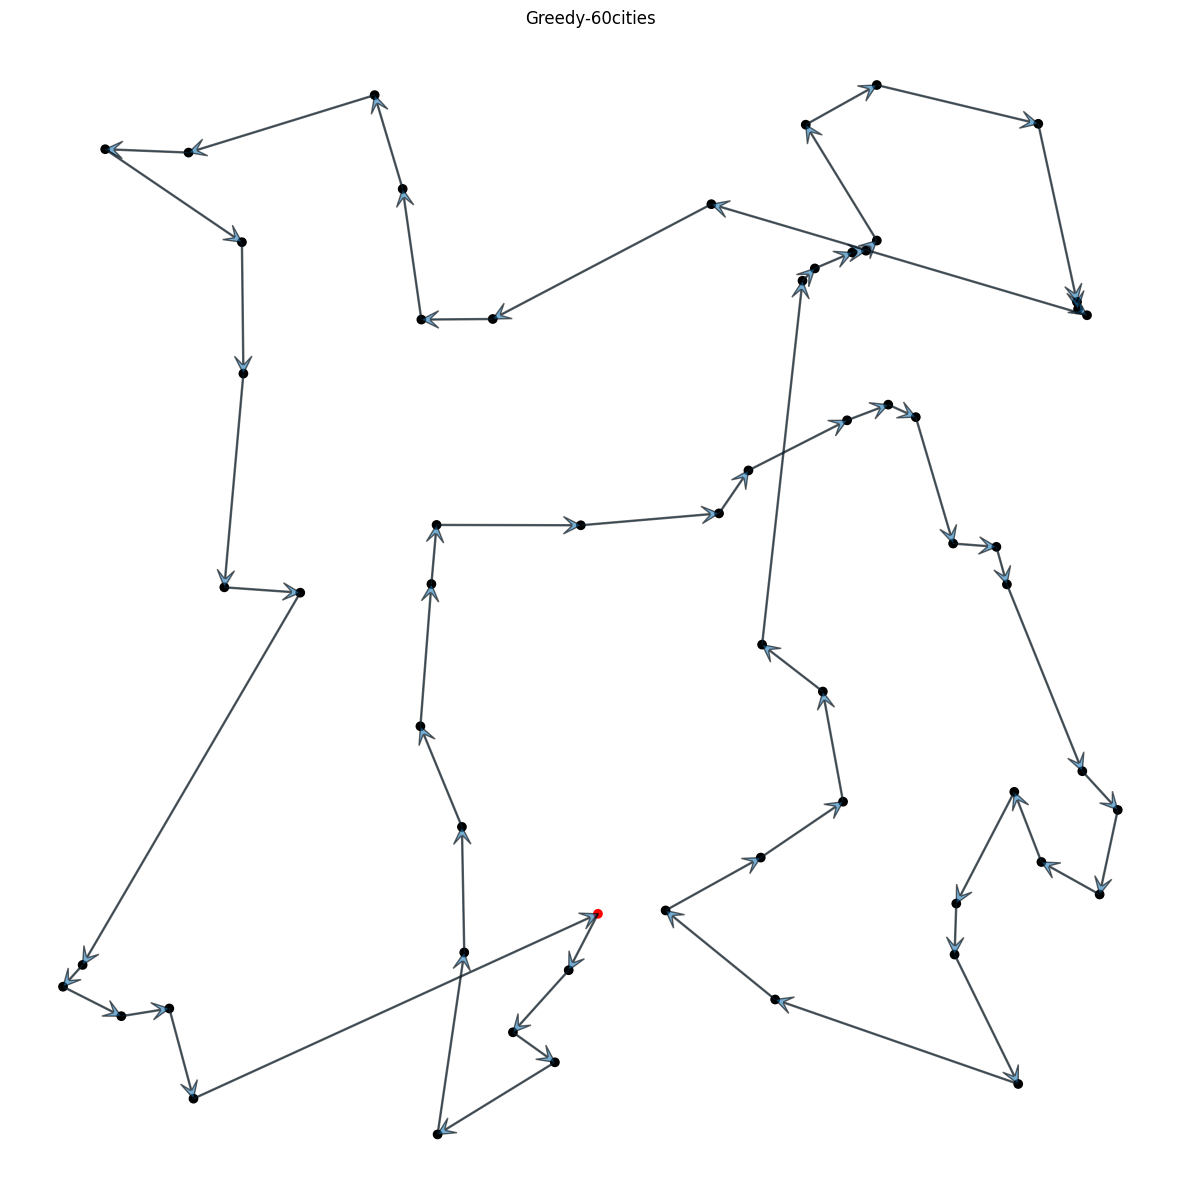

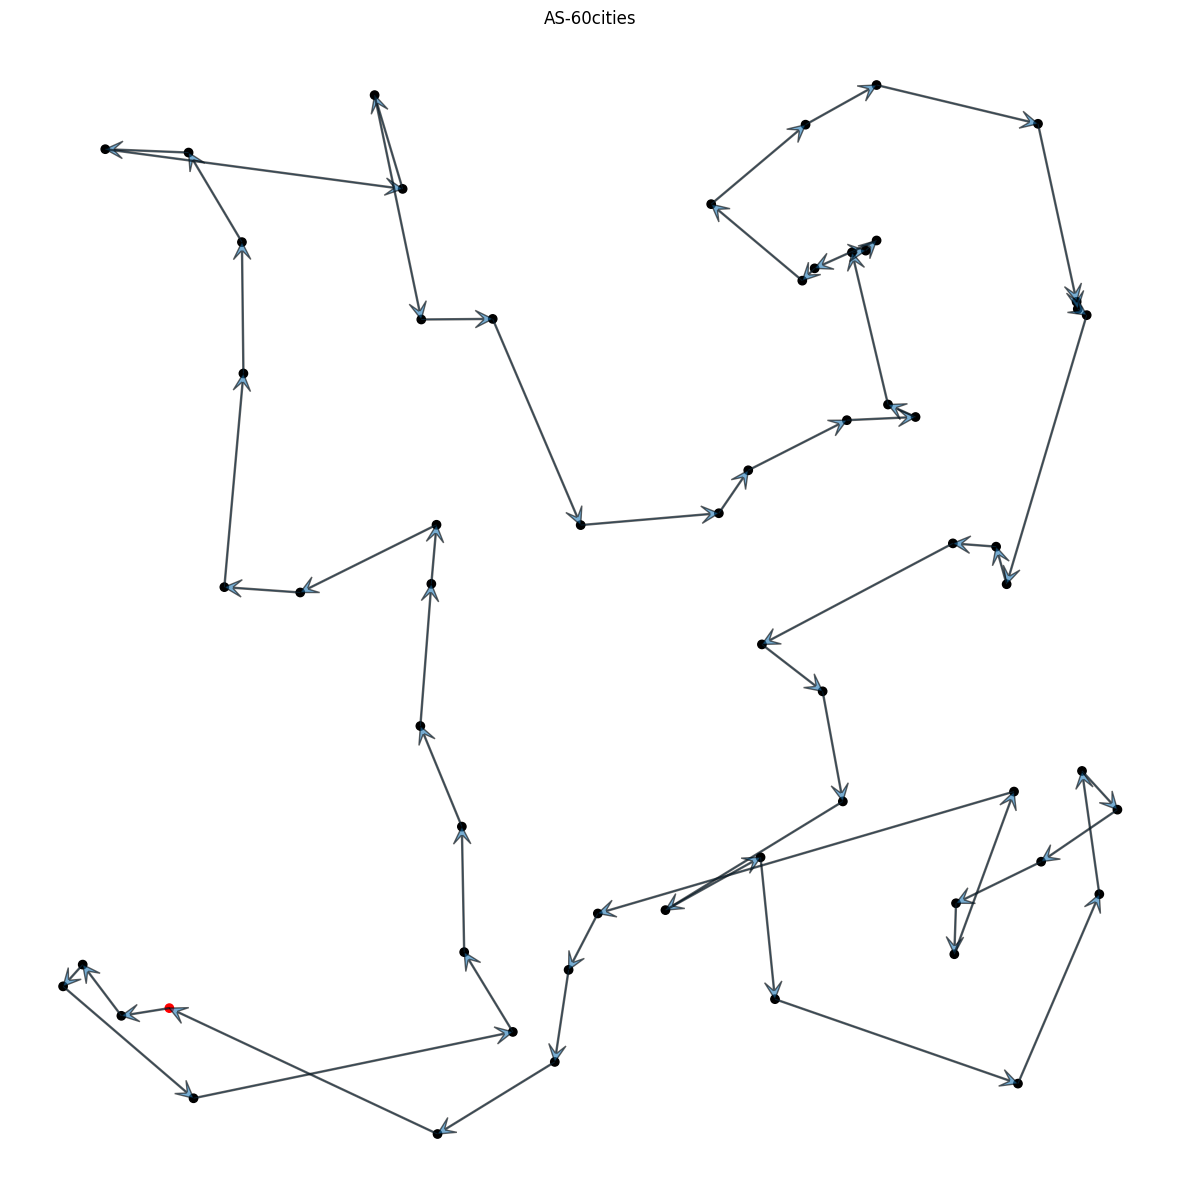

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_12272\1439634510.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


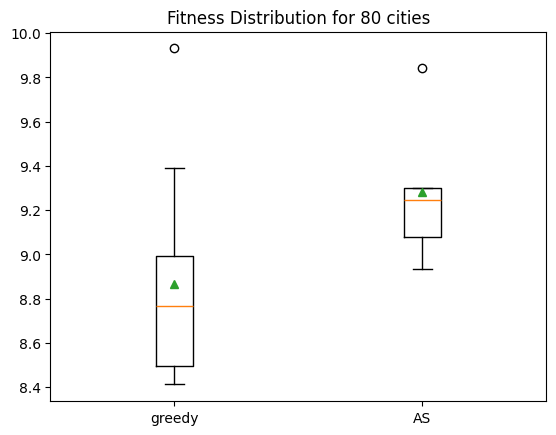

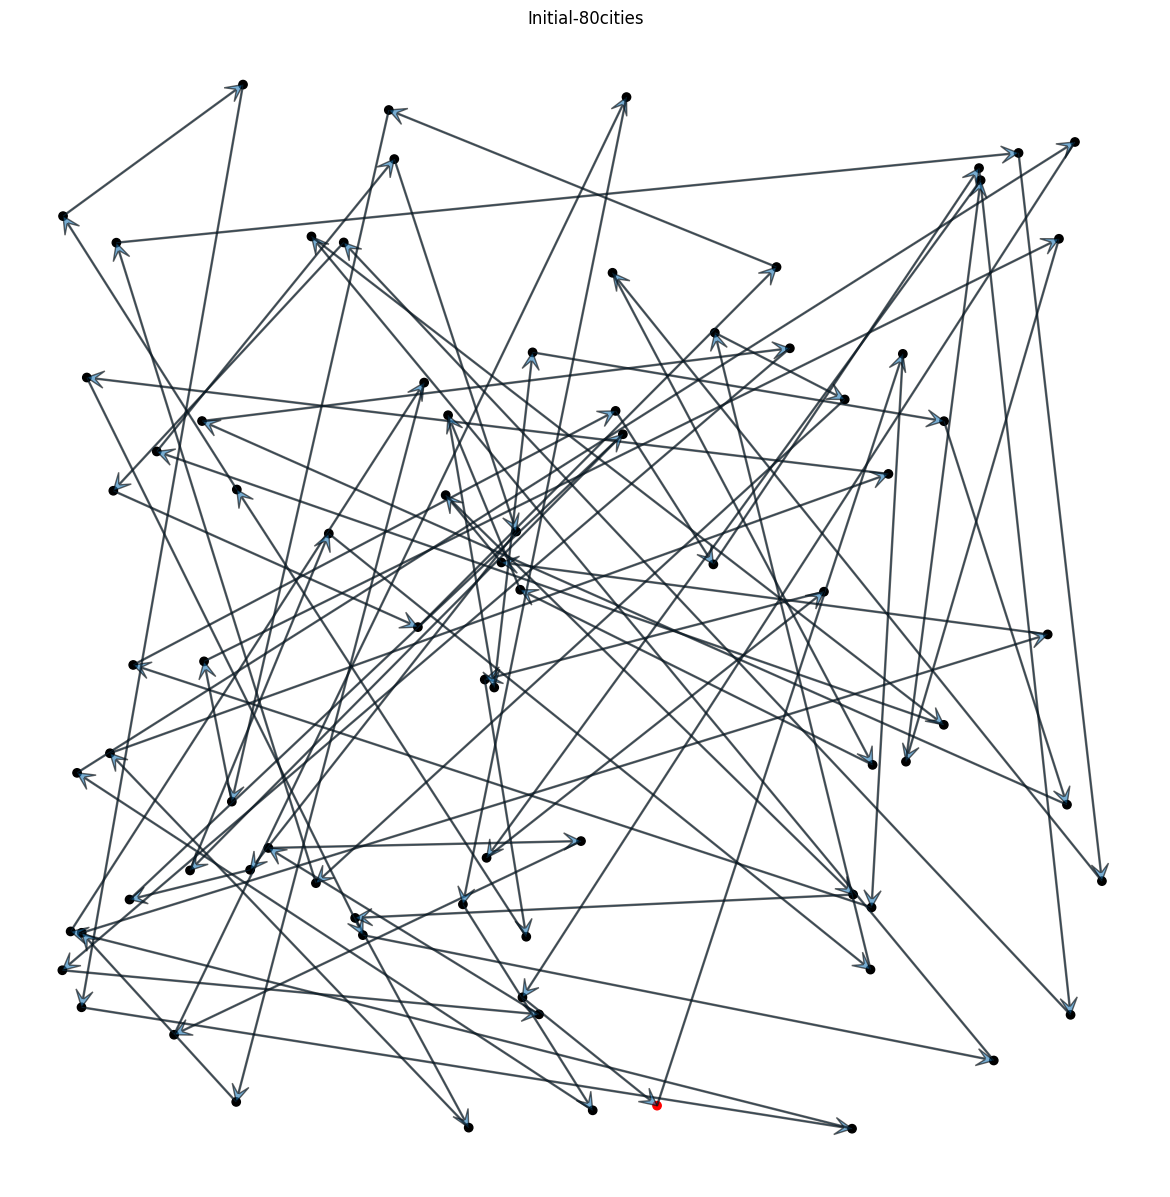

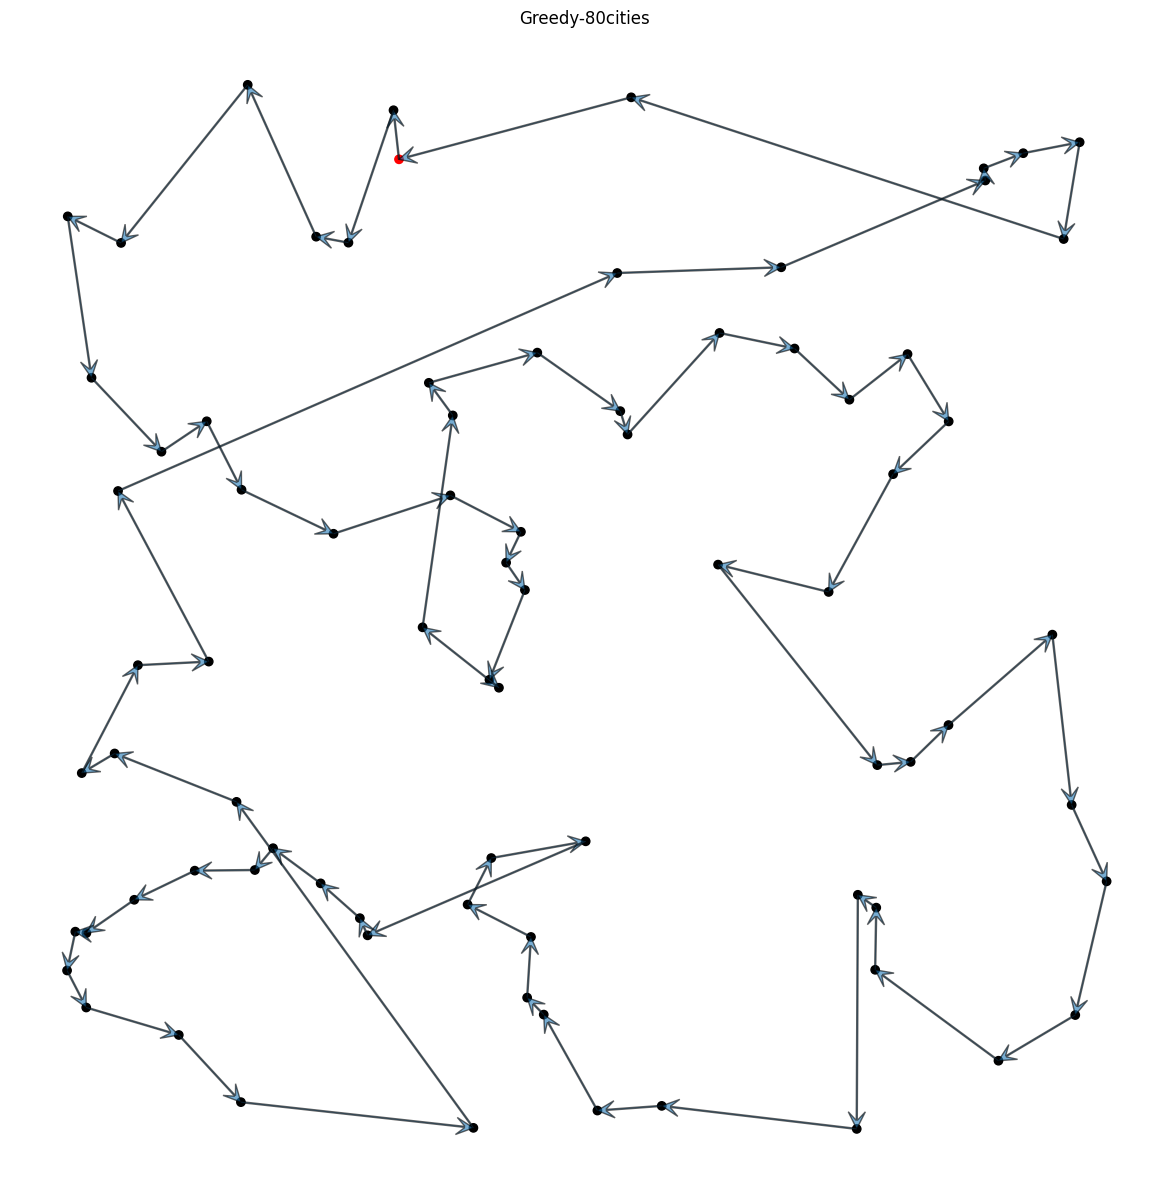

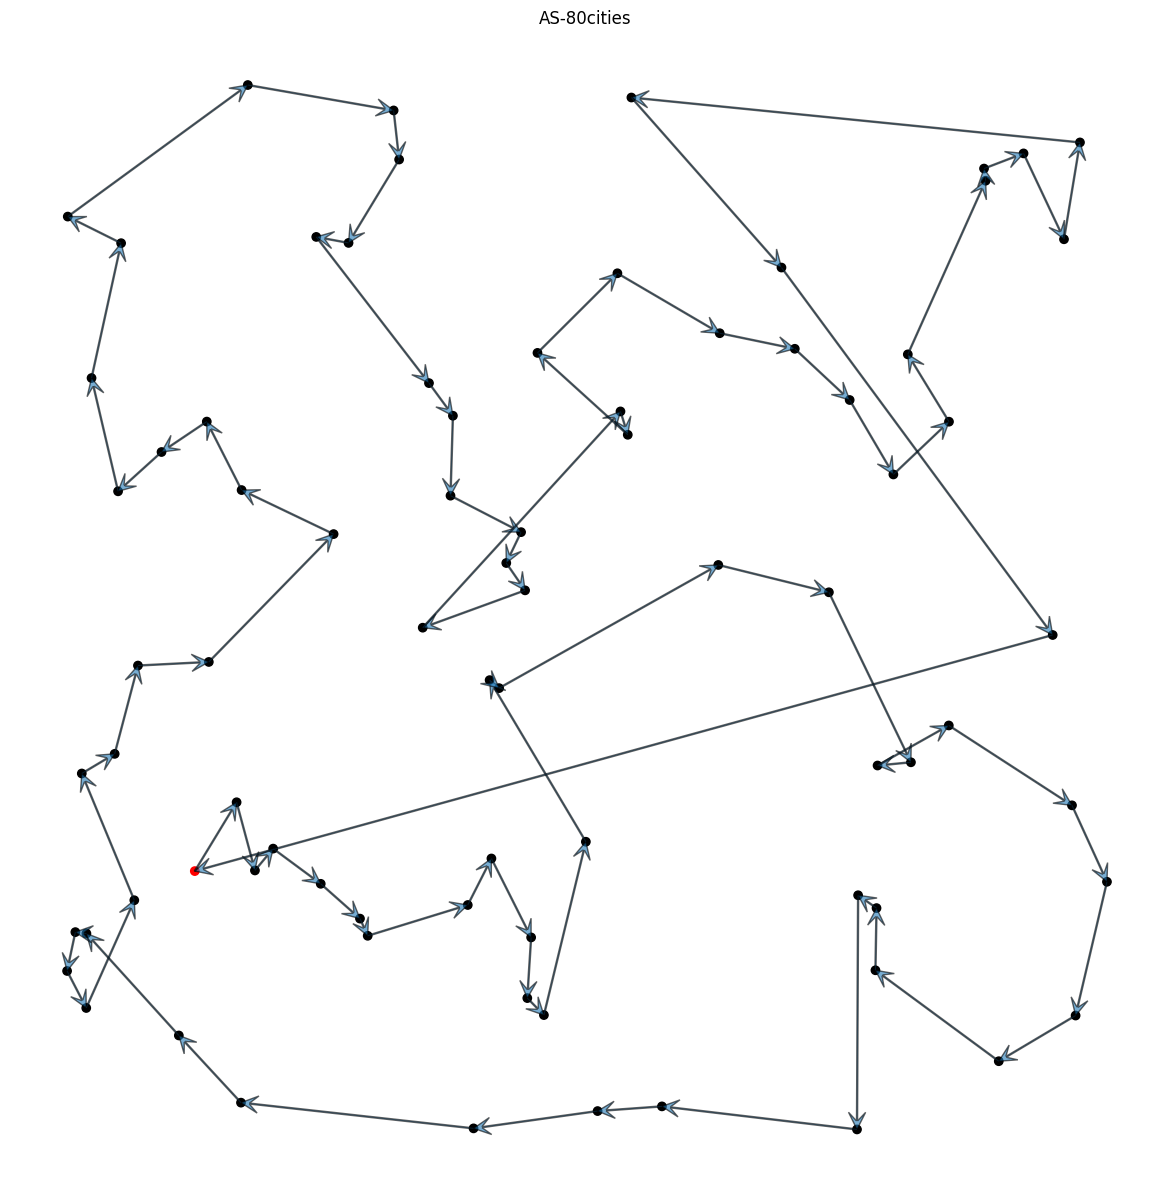

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_12272\1439634510.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


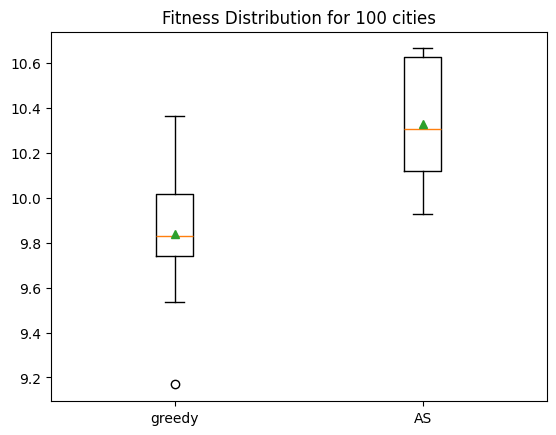

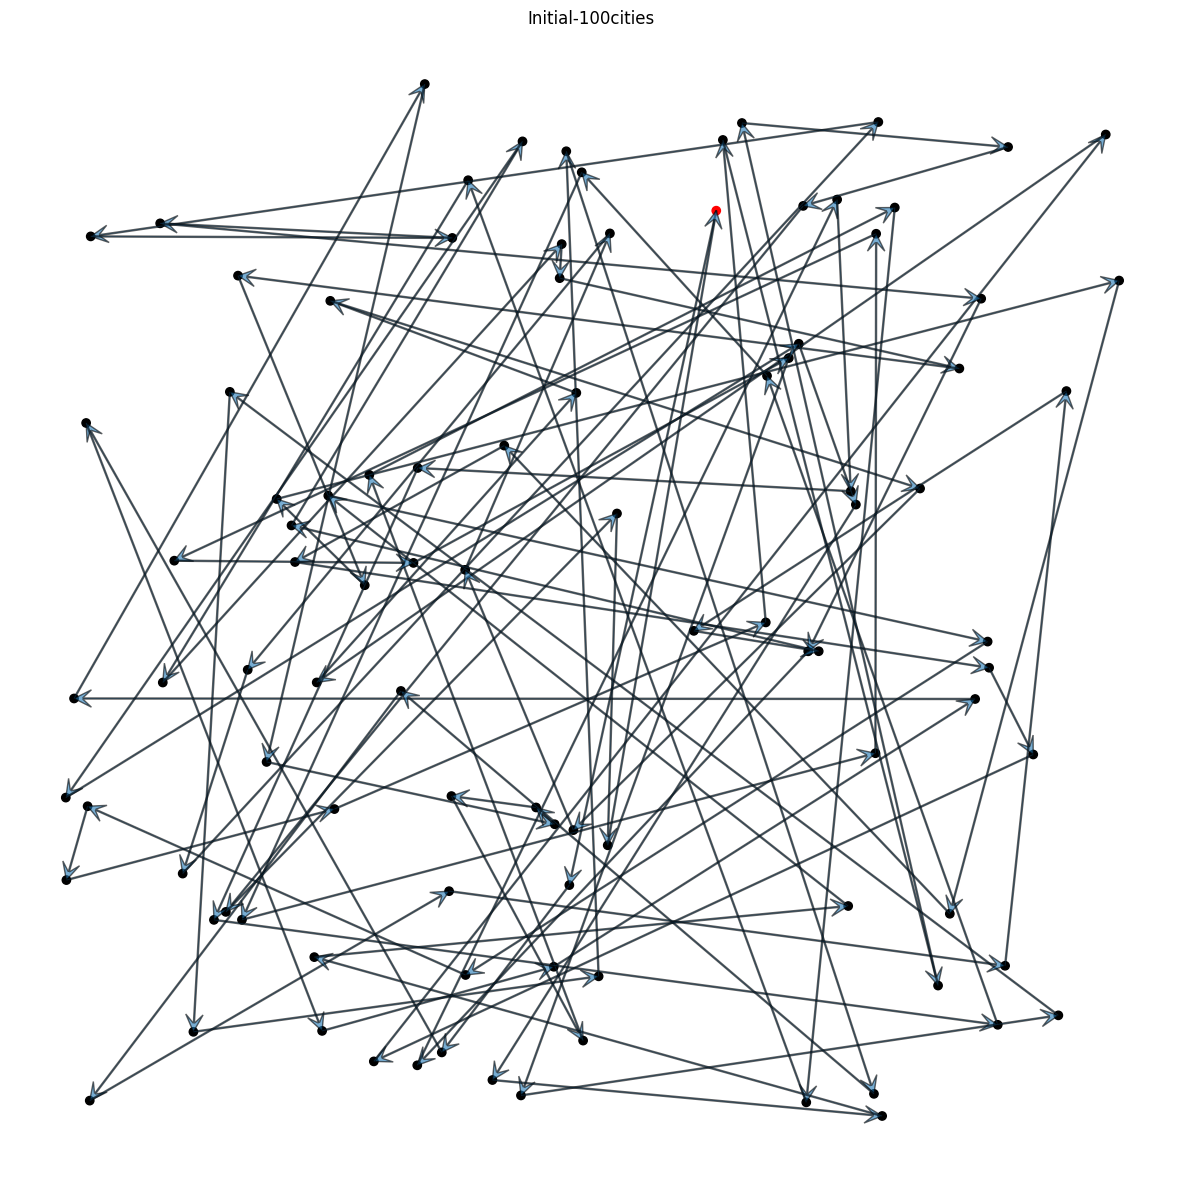

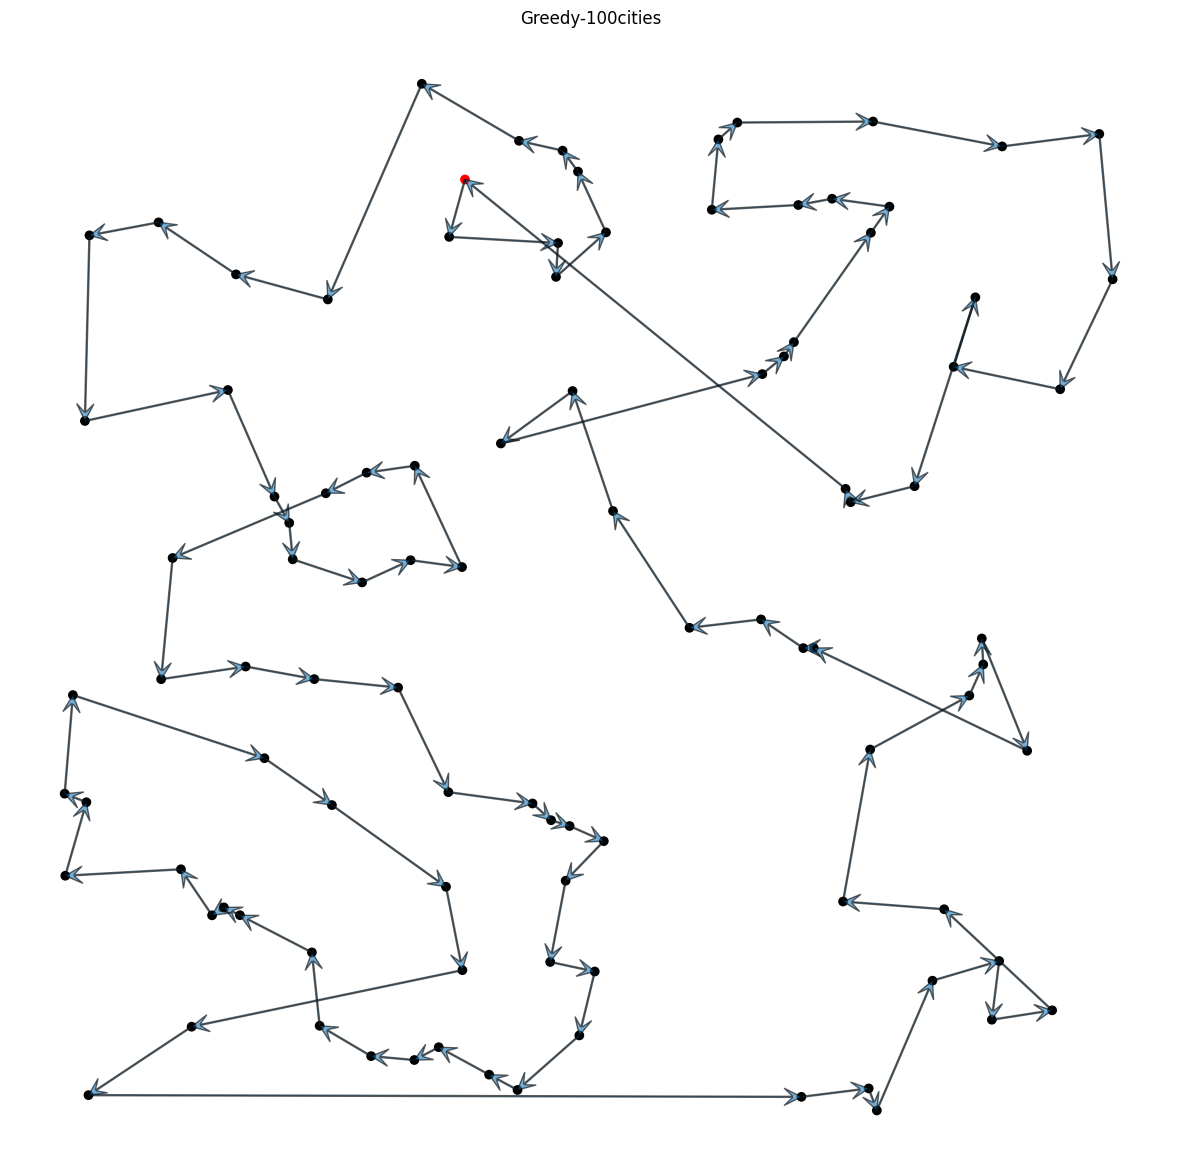

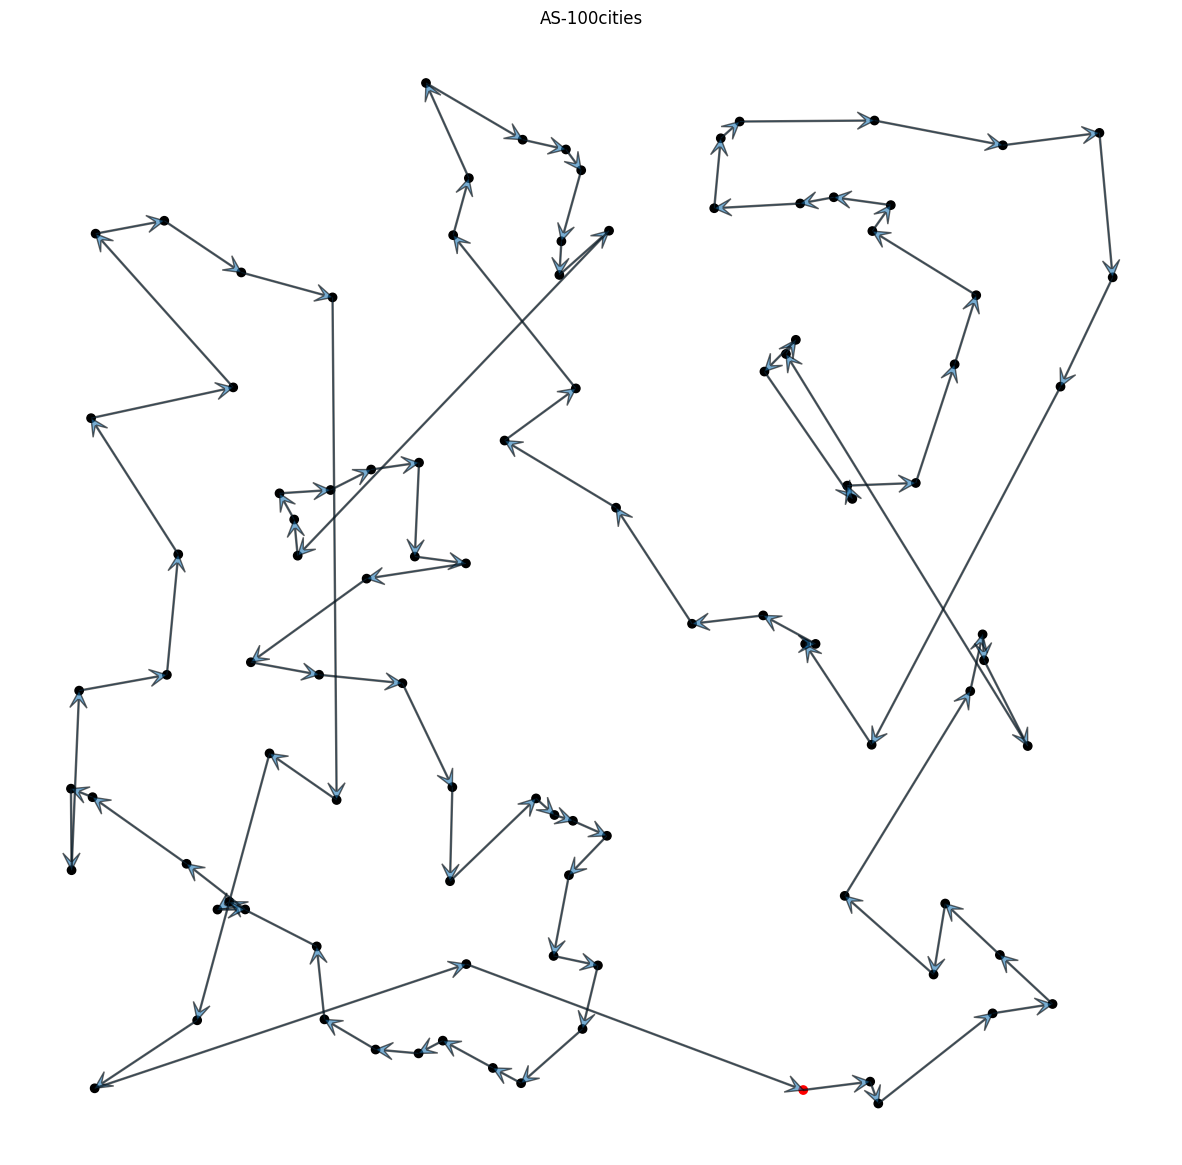

In [50]:
## compare greedy vs AS for 'cities.dat', 'cities2.dat', and 50, 60, 80, & 100 cities' configurations
at1.compare_methods(filename="c1")
at2.compare_methods(filename="c2")
for k in [50, 60, 80, 100]:
    at = AT(np.random.rand(k, 3))
    at.compare_methods(filename=f'dpt_{k}')

#### Comment on the results for Ant System (AS) vs. Greedy

Results are obtained for $30$ ants and $80$ iterations.
We can constate on plots that Ant System algorithm works quite well.
In mean, the Ant System algorithm is better than the greedy algorithm for number of cities until $50$.
Then, the greedy algorithm has a better mean, as shown on the fitness distribution plots.
And if we look at the standard deviation of solutions given, the standard deviation of the Ant System algorithm is better than the standard deviation of greedy algorithm, except for $100$ cities.
Finally, the variance of the Ant System algorithm is smaller than for the greedy algorithm because most of values are more concentrated around the mean.
It means that the Ant System algorithm seems to be more stable than the greedy algorithm because results are more concentrated around the mean.
And it can also signifies that the Ant System give results as better as the greedy algorithm for not too big number of cities.
I think that for more bigger number of cities, if we increase the number of iterations or of ants, we can increase the accuracy of our result, as discussed before, at the cost of execution time.

So for not too big number of cities, Ant System give better results than greedy, and in general, results of Ant System algorithm are more stable and less varies than greedy results.
However Ant System is costly in execution time.


#### Compare and discuss the performance of the Ant System (AS) and the Simulated Annealing (SA) algorithms applied on the TSP in terms of their solution quality and execution time.

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_15216\2847670674.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


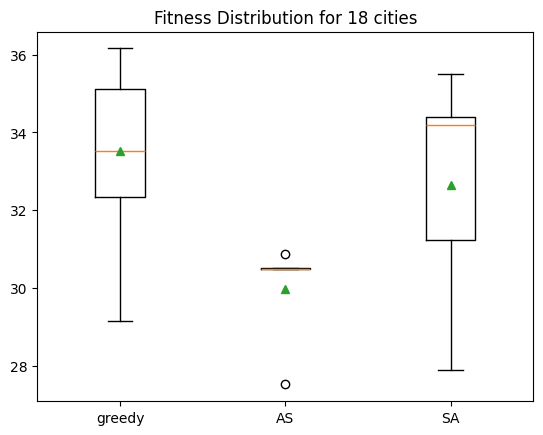

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_15216\2847670674.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


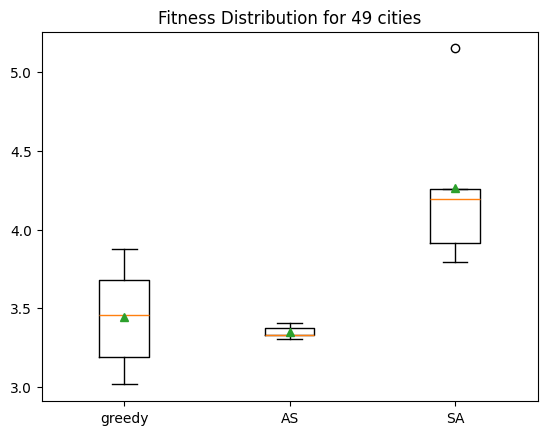

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_15216\2847670674.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


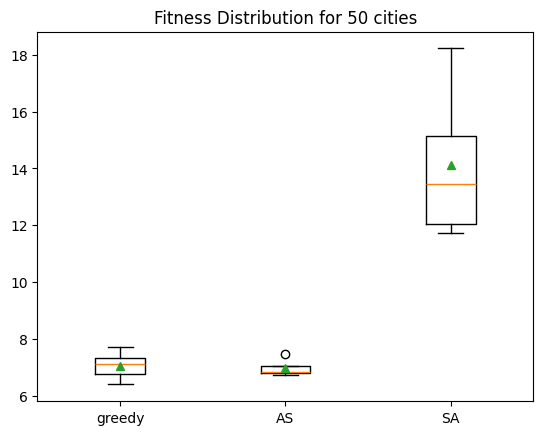

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_15216\2847670674.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


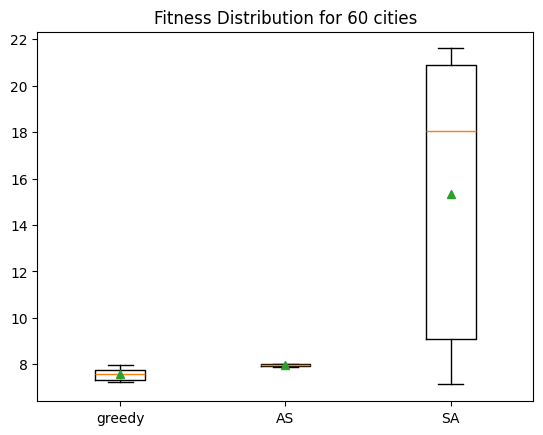

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_15216\2847670674.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


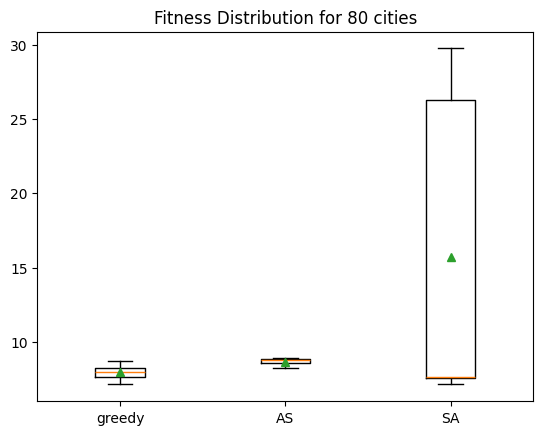

C:\Users\Sinbad\AppData\Local\Temp\ipykernel_15216\2847670674.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxes.values(), showmeans = True, labels=list(boxes.keys()))


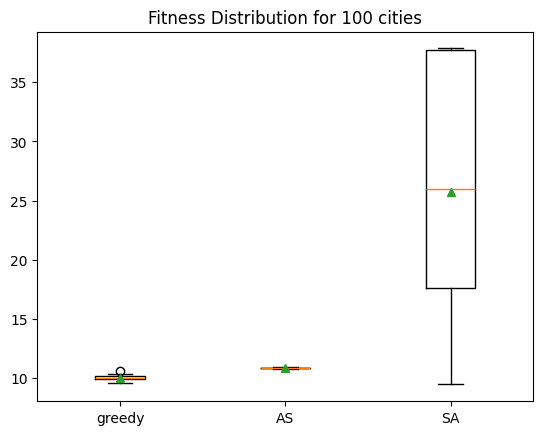

In [5]:
## compare greedy vs AS for 'cities.dat', 'cities2.dat', and 50, 60, 80, & 100 cities' configurations
at1.compare_methods(filename="c1", sa=True)
at2.compare_methods(filename="c2", sa=True)
for k in [50, 60, 80, 100]:
    at = AT(np.random.rand(k, 3))
    at.compare_methods(filename=f'dpt_{k}', sa=True)

To compare both algorithms, I just copy paste my implementation from last TP and I set the Simulated Annealing with the best parameters tested in previous TP, so an acceptance rate of $5\%$ and a Temperature schedule of $0.95$.

### Execution time

If we look at the execution time, both Ant System and Simulated Annealing algorithm are heavy for computation time, compared to a greedy algorithm.
But the Simulated Annealing is faster than the Ant System.
For instance, for cities.dat problem, Simulated Annealing algorithm is approximatively $15 \times$ faster than the Ant System and for random $100$ cities, Simulated Annealing is approximatively $5 \times$ faster.
So it means that more big is the problem, more the Ant System is efficient because it becomes from $15\times$ to $5\times$ slower when the problem increase from $18$ to $100$ cities.
It's normal because the number of ants and of iterations is fixed in case of Ant System algorithm,
and the algorithm is parallelized for each ants.
So for bigger problem, the parallelization will be more efficient than for smaller problems where computations units don't work a lot and take time to distribute tasks between them.

### Quality of solutions

The Ant System algorithm give always better results than Simulated Annealing algorithm in all cases.
However, we can constate that the results of Simulated Annealing become worst when the size of the problem increase, because for $18$ cities, the quality of results given by Ant System is $1.1\times$ better than Simulated Annealing and for $100$ cities, it is $2.5\times$ better.
One might have thought that for the same computational cost, the results would have been identical.
But this result shows that the Ant System method is better, even at the same cost, for this TSP problem because with time execution of Ant System that becomes closest to time execution of Simulated Annealing, quality of results stay far away results of Simulated Annealing.

If we look at the plots of fitness distribution, we can easily see that the variations in results is greater in case of Simulated Annealing compared to Ant System.
On top of that, when increasing the size of the problem, the results vary even more.

So the Simulated Annealing method may be faster than the Ant System method, but it is also less stable and produces much poorer results for this TSP problem.
However, we may wonder us if for another problem, the Simulated Annealing method could be better than the Ant System method.

### Answer the following Questions: 

1.  Q: What is the Search Space for Ant System algorithm? (given number of cities = n, & number of ants = m)

    A: The search space of the TSP problem is the number of paths that differs from other.
    As a path is cyclic, it means that path [1, 2, 3] is the same than path [3, 2, 1] or path [3, 1, 2] because if we start from city $i$ and achieve our cycle by going left, it's the same that starting from city $j$ and making the cycle by going right.
    If we have $n$ cities, the number of path possible are given by $n \times (n - 1) \times (n - 2) \times \cdots \times 1 = n!$
    For each path, the number of right cycles is the number of right shifts possible before having the same initial path.
    So this number is of $n$ because after, we return on initial configuration.
    So the number of left cycles is also $n$.
    So for TSP, the search space is :
    $$\dfrac{n!}{2n} = \dfrac{(n- 1)!}{2}$$
    
    For the Ant System algorithm, there are $m$ ants that explore the search space of TSP.
    So as each ant is totaly independant from each other, it means that at each iteration, the possibilites of explorations are given by
    $$\underbrace{\dfrac{(n- 1)!}{2} \times \cdots \times \dfrac{(n- 1)!}{2}}_{m \ \text{times}} = \dfrac{(n- 1)!}{2}^m$$
    So the search space for Ant System is given by $\dfrac{(n- 1)!}{2}^m$.

2.  Q: Can you describe the neighborhood in this case?

    A: In this case, describing the neighborhood is not relevant because each ants start randomly in the search space and create a path according to probabilities and pheromones.
    So there is no link between two paths, except for the pheromones deposited.
    In this way, it's not relevant to speak about neighborhood because next path is guided only by pheromones and not by last path, so no neighborhood can be constructed from a given path.

3.  Q: Talk about the impact of parameters $\alpha$, $\beta$, & $\rho$

    A:
